#  London Bike Sharing - Machine Learning Projekt

##  Zusammenfassung

### Projektziel
Entwicklung eines **Demand Forecasting Systems** für Londoner Bike-Sharing mit Fokus auf:
- **Asymmetrische Kosten:** Stockouts (fehlende Räder) sind 2.5x teurer als Überkapazität
- **Zeitreihen-Validierung:** TimeSeriesSplit zur Vermeidung von Data Leakage
- **Business-Relevanz:** Cost-Benefit-Analyse und realistische KPIs

### Methodischer Ansatz
1. **Explorative Datenanalyse (EDA):** 11+ Visualisierungen zu Mustern und Zusammenhängen
2. **Feature Engineering:** Zyklische Features, Interaktionen, temporale Features
3. **Modell-Benchmarking:** 13 Algorithmen mit 4 Skalierungen = 25+ Kombinationen
4. **Advanced Techniques:** Post-Processing, Custom Transformer, Ensemble-Learning
5. **Business-Auswertung:** Kategorisierung, Kosten-Simulation, Performance-Analyse

### Erwartete Ergebnisse
- **Target R²:** > 0.90
- **Target Asymmetric Score:** 80-85%
- **Bestes Modell:** KNN Custom + Post-Processing oder GradBoost Quantile

### Team-Mitglieder
- **René Lemke:** Feature Engineering (sin/cos), GridSearch, Hyperparameter-Tuning BayesRidgeRegression, Visualisierungen, Code-Dokumentation
- **Finn Hößler:** Custom Scoring Function, OOF-Optimizer, Visualisierungen, Hyperparameter-Tuning RandomForestRegressor
- **Shiar Hido:** Post-Processing, Hyperparameter-Tuning KNeighborsRegressor, Visualisierungen, Datenanalyse
- **Juri Blank:** Systematische Modell-Evaluierung (13 Algorithmen), Code-Dokumentation, Hyperparameter-Tuning GradienBoostRegressorQ85, Visualisierungen, Datenanalyse

**Datum:** 12. Dezember 2025

## 1. Imports & Setup

Wir importieren alle benötigten Bibliotheken und konfigurieren die Umgebung:
- **Datenverarbeitung:** pandas, numpy
- **Visualisierung:** matplotlib, seaborn
- **Machine Learning:** sklearn (13 Algorithmen)
- **Reproduzierbarkeit:** RANDOM_STATE = 42

In [20]:
# ==================================================================================
# 1. IMPORTS & SETUP
# ==================================================================================

# Datenverarbeitung & Numerik
import numpy as np
import pandas as pd

# Visualisierung
import matplotlib.pyplot as plt
import seaborn as sns

# System & Utilities
import warnings
import time
import joblib
from datetime import datetime
from IPython.display import display, HTML

# Sklearn: Preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin

# Sklearn: Model Selection & Validation
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score
from sklearn.metrics import (
    r2_score, 
    mean_absolute_error, 
    mean_squared_error, 
    mean_absolute_percentage_error, 
    make_scorer
)

# Sklearn: Modelle (Linear)
from sklearn.linear_model import LinearRegression, Ridge, Lasso, BayesianRidge

# Sklearn: Modelle (Distance-based)
from sklearn.neighbors import KNeighborsRegressor

# Sklearn: Modelle (Tree-based)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, 
    GradientBoostingRegressor, 
    ExtraTreesRegressor, 
    AdaBoostRegressor, 
    VotingRegressor
)

# Sklearn: Modelle (SVM & Neural Networks)
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

#für KnnBikeTransformer
from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.pipeline import Pipeline

# ==================================================================================
# KONFIGURATION
# ==================================================================================

# Warnungen unterdrücken (für cleane Outputs)
warnings.filterwarnings('ignore')

# Plot-Styling
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

# Reproduzierbarkeit sicherstellen
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ==================================================================================
# PROJEKT-BANNER
# ==================================================================================

print("="*80)
print("LONDON BIKE SHARING - ML-PROJEKT")
print("="*80)
print("✓ Umfassende EDA mit 11+ Visualisierungen")
print("✓ Erweiterte Hyperparameter-Grids (echtes Tuning)")
print("✓ Multiple Scoring-Methoden (R², MAE, MAPE, Custom)")
print("✓ Advanced Post-Processing (Bias-Korrektur)")
print("✓ Voting Regressor Ensemble")
print("✓ Robuste TimeSeriesSplit (5 Folds)")
print("✓ Feature Importance & Residuals Analyse")
print("✓ Model Persistence & Business-Kategorisierung")
print("="*80)

LONDON BIKE SHARING - ML-PROJEKT
✓ Umfassende EDA mit 11+ Visualisierungen
✓ Erweiterte Hyperparameter-Grids (echtes Tuning)
✓ Multiple Scoring-Methoden (R², MAE, MAPE, Custom)
✓ Advanced Post-Processing (Bias-Korrektur)
✓ Voting Regressor Ensemble
✓ Robuste TimeSeriesSplit (5 Folds)
✓ Feature Importance & Residuals Analyse
✓ Model Persistence & Business-Kategorisierung


## 2. Custom Scoring Functions

Wir definieren **4 verschiedene Scoring-Methoden** für unterschiedliche Perspektiven:

### 1. Symmetric Tolerance (±15%)
Klassische Toleranzband-Metrik, symmetrisch
- **Use-Case:** Baseline-Vergleich, faire Bewertung

### 2. Asymmetric Simple
Binäre Business-Toleranz (-5% bis +20%)
- **Use-Case:** Quick-Check für Business-Akzeptanz

### 3. Asymmetric Weighted  **PRIMÄRE METRIK**
Kontinuierlicher Score mit asymmetrischer Gewichtung:
- **Untervorhersagen:** 2.5x Penalty (Stockouts = verlorene Kunden)
- **Übervorhersagen:** 0.8x Penalty (Überkapazität = Wartungskosten)
- **Nachfrage-Gewichtung:** sqrt(y_true) für Priorisierung von Rush-Hours
- **Use-Case:** PRIMÄRE METRIK für Model Selection

### 4. MAE & MAPE
Standard-Metriken für Regression
- **Use-Case:** Vergleichbarkeit mit Literatur

In [21]:
# ==================================================================================
# 2. CUSTOM SCORING FUNCTIONS
# ==================================================================================

def tolerance_score_symmetric(y_true, y_pred, tol=0.15):
    """
    Berechnet den Prozentsatz der Vorhersagen innerhalb einer symmetrischen Toleranz.
    
    Parameters:
    -----------
    y_true : array-like
        Tatsächliche Werte (echte Nachfrage)
    y_pred : array-like
        Vorhergesagte Werte (Modell-Output)
    tol : float, default=0.15
        Toleranz als Dezimalzahl (0.15 = ±15%)
    
    Returns:
    --------
    float
        Prozentsatz der Vorhersagen innerhalb der Toleranz (0-100)
    
    Beispiel:
    ---------
    Wenn 85% der Vorhersagen im ±15%-Band liegen → Score = 85.0
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    
    # Relativen Fehler berechnen, Division durch 0 vermeiden
    with np.errstate(divide='ignore', invalid='ignore'):
        diff = np.abs((y_true - y_pred) / y_true)
    
    # Sonderfall: y_true = 0 → setze Fehler auf 0 (keine Nachfrage)
    diff[y_true == 0] = 0
    
    return np.mean(diff <= tol) * 100


def bike_score_asymmetric_simple(y_true, y_pred):
    """
    Asymmetrischer Business Score (Binär-Version).
    
    Toleranzband: -5% (Unterversorgung) bis +20% (Überversorgung)
    
    Returns:
    --------
    float
        Prozentsatz der Vorhersagen im Business-Toleranzband (0-100)
    
    Interpretation:
    ---------------
    - < 75%: Inakzeptabel (zu viele Ausreißer)
    - 75-85%: Akzeptabel (Standard-Performance)
    - > 85%: Exzellent (Production-Ready)
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    
    # Business-Grenzen definieren
    lower = y_true * 0.95  # -5% Toleranz nach unten
    upper = y_true * 1.20  # +20% Toleranz nach oben
    
    # Boolean-Maske: True wenn innerhalb des Bands
    ok = (y_pred >= lower) & (y_pred <= upper)
    
    return np.mean(ok) * 100


def bike_score_asymmetric_weighted(y_true, y_pred):
    """
    Asymmetrischer Business Score mit kontinuierlicher Gewichtung.
    
    *** PRIMÄRE METRIK FÜR MODEL SELECTION ***
    
    Gewichtungslogik:
    -----------------
    1. Innerhalb Toleranzband (-5% bis +20%): Score = 1.0 (perfekt)
    
    2. Untervorhersagen (y_pred < y_true * 0.95):
       - Penalty = 2.5 × relativer_fehler × sqrt(nachfrage)
       - Stockouts sind kritisch → hohe Gewichtung
       - Bei hoher Nachfrage noch kritischer → sqrt-Skalierung
    
    3. Übervorhersagen (y_pred > y_true * 1.20):
       - Penalty = 0.8 × relativer_fehler × sqrt(nachfrage)
       - Überkapazität ist günstiger → niedrige Gewichtung
    
    4. Nachfrage-Gewichtung:
       - weight = sqrt(y_true) / mean(sqrt(y_true))
       - Hohe Nachfrage = wichtiger (Rush-Hour, Events)
       - Niedrige Nachfrage = weniger kritisch (Nachts)
    
    Returns:
    --------
    float
        Gewichteter Score zwischen 0 und 1 (als Dezimalzahl)
        Für Prozent: Wert × 100
    
    Beispiel:
    ---------
    Score = 0.82 → 82% gewichtete Performance
    """
    y_true = np.array(y_true).astype(float)
    y_pred = np.array(y_pred).astype(float)
    
    # Business-Grenzen
    lower = y_true * 0.95
    upper = y_true * 1.20
    
    # Initial: Alle Predictions bekommen Score = 1.0
    score = np.ones_like(y_true, dtype=float)
    
    # Masken für die 3 Fälle erstellen
    in_band = (y_pred >= lower) & (y_pred <= upper)  # OK: Keine Änderung
    outside = ~in_band  # Außerhalb Band
    under = y_pred < lower  # Unterversorgung
    over = y_pred > upper  # Überversorgung
    
    # Relativer Fehler berechnen
    err_ratio = np.abs(y_pred - y_true) / (y_true + 1e-9)  # +epsilon für Stabilität
    
    # Nachfrage-Gewichtung (sqrt-Normalisierung)
    weight = np.sqrt(y_true)
    weight = weight / (np.mean(weight) + 1e-9)  # Normalisierung auf Mittelwert = 1
    
    # Penalties berechnen
    penalty_under = 2.5 * err_ratio * weight  # Hohe Penalty für Stockouts
    penalty_over = 0.8 * err_ratio * weight   # Niedrige Penalty für Waste
    
    # Penalties anwenden (nur außerhalb des Toleranzbands)
    score[outside & under] -= penalty_under[outside & under]
    score[outside & over] -= penalty_over[outside & over]
    
    # Scores auf [0, 1] clippen (negative Scores = 0)
    score = np.clip(score, 0.0, 1.0)
    
    return float(np.mean(score))


def custom_mae_scorer(y_true, y_pred):
    """
    Negative MAE für GridSearchCV.
    
    GridSearchCV maximiert Scores → MAE muss negiert werden.
    """
    return -mean_absolute_error(y_true, y_pred)


def custom_mape_scorer(y_true, y_pred):
    """
    Negative MAPE für GridSearchCV.
    
    Achtung: MAPE problematisch bei y_true nahe 0!
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0  # Nur Werte != 0 verwenden
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return -mape


# ==================================================================================
# SKLEARN-KOMPATIBLE SCORER ERSTELLEN
# ==================================================================================

scorer_r2 = 'r2'  # Built-in Scorer
scorer_mae = make_scorer(custom_mae_scorer, greater_is_better=True)
scorer_mape = make_scorer(custom_mape_scorer, greater_is_better=True)
scorer_asymmetric = make_scorer(bike_score_asymmetric_weighted, greater_is_better=True)

# Dictionary für einfachen Zugriff
SCORERS = {
    'R2': scorer_r2,
    'MAE': scorer_mae,
    'MAPE': scorer_mape,
    'Asymmetric_Weighted': scorer_asymmetric
}

print(" Custom Scoring Functions definiert")
print(" 4 Metriken verfügbar: R², MAE, MAPE, Asymmetric_Weighted")

 Custom Scoring Functions definiert
 4 Metriken verfügbar: R², MAE, MAPE, Asymmetric_Weighted


## 3. Daten laden & bereinigen

### Datenquelle
- **Datei:** `london_merged.csv`
- **Zeitraum:** 2015-2017 (stündliche Auflösung)
- **Features:** Temperatur, Wetter, Feiertage, Zeitangaben

### Preprocessing-Schritte
1. **Streiktage entfernen:** 2015-07-09, 2015-08-06 (Business-Logic)
2. **Zeitstempel parsen:** Konvertierung zu datetime64
3. **Validierung:** Prüfung auf fehlende Werte

In [22]:
print("\n" + "="*80)
print(" PHASE 1: DATEN LADEN & BEREINIGEN")
print("="*80)

# CSV einlesen
df = pd.read_csv("london_merged.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Streiktage entfernen (Business-Logic)
# An diesen Tagen gab es keine regulären Fahrten → würden Modell verzerren
strike_dates = ['2015-07-09', '2015-08-06']
rows_before = len(df)
df = df[~df['timestamp'].dt.strftime('%Y-%m-%d').isin(strike_dates)]

print(f"✓ Streiktage entfernt: {rows_before - len(df)} Zeilen")
print(f"✓ Finale Datenmenge: {len(df):,} Zeilen")
print(f"✓ Fehlende Werte: {df.isnull().sum().sum()}")

# Datenübersicht anzeigen
print("\nDatensatz Info:")
display(df.head())
display(df.describe())
print(f"\nZeitraum: {df['timestamp'].min()} bis {df['timestamp'].max()}")
print(f"Features: {list(df.columns)}")


 PHASE 1: DATEN LADEN & BEREINIGEN
✓ Streiktage entfernt: 48 Zeilen
✓ Finale Datenmenge: 17,366 Zeilen
✓ Fehlende Werte: 0

Datensatz Info:


,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,3.0
1,2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,3.0
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,3.0
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3.0
4,2015-01-04 04:00:00,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,3.0


,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
count,17366,17366.000000,17366.000000,17366.000000,17366.000000,17366.000000,17366.000000,17366.000000,17366.000000,17366.000000
mean,2016-01-04 09:25:35.275826176,1138.431418,12.451102,11.501574,72.363598,15.918524,2.725786,0.022112,0.286191,1.493435
min,2015-01-04 00:00:00,0.000000,-1.500000,-6.000000,20.500000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,2015-07-04 08:15:00,256.000000,8.000000,6.000000,63.000000,10.000000,1.000000,0.000000,0.000000,0.000000
50%,2016-01-04 15:30:00,842.000000,12.500000,12.500000,75.000000,15.000000,2.000000,0.000000,0.000000,1.000000
75%,2016-07-05 03:45:00,1663.000000,16.000000,16.000000,83.000000,20.500000,3.000000,0.000000,1.000000,2.000000
max,2017-01-03 23:00:00,5560.000000,34.000000,34.000000,100.000000,56.500000,26.000000,1.000000,1.000000,3.000000
std,NaN,1076.316975,5.567944,6.612455,14.291421,7.901941,2.342735,0.147053,0.451993,1.120157



Zeitraum: 2015-01-04 00:00:00 bis 2017-01-03 23:00:00
Features: ['timestamp', 'cnt', 't1', 't2', 'hum', 'wind_speed', 'weather_code', 'is_holiday', 'is_weekend', 'season']


## 4. Feature Engineering

### Neue Features erstellen:

#### Zeitliche Features
- `hour`, `month`, `day_of_week`: Diskrete Zeitangaben
- `is_weekend`: Boolean für Wochenenden

#### Zyklische Features (WICHTIG für Kontinuität!)
- `hour_sin/cos`: 23 Uhr ist näher an 0 Uhr als an 12 Uhr
- `month_sin/cos`: Dezember ist näher an Januar als an Juni

#### Interaktions-Features
- `temp_humidity`: Fühltemperatur (Temperatur × Luftfeuchtigkeit)
- `windspeed_weather`: Kombinierter Wetter-Einfluss

In [23]:
print("\n" + "="*80)
print(" PHASE 2: FEATURE ENGINEERING")
print("="*80)

# Zeit-Features extrahieren
df['hour'] = df['timestamp'].dt.hour
df['month'] = df['timestamp'].dt.month
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# Zyklische Features (wichtig für zeitliche Kontinuität!)
# Verhindert "Sprünge" zwischen Ende und Anfang des Zyklus
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12.0)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12.0)

# Interaktions-Features
# Kombinieren verwandte Features für komplexere Muster
df['temp_humidity'] = df['t1'] * df['hum']
df['windspeed_weather'] = df['wind_speed'] * df['weather_code']

features_created = len([c for c in df.columns if c not in ['timestamp', 'cnt']])
print(f"Features erstellt: {features_created}")
print(f"\nFeature-Liste: {[c for c in df.columns if c not in ['timestamp', 'cnt']]}")


 PHASE 2: FEATURE ENGINEERING
Features erstellt: 17

Feature-Liste: ['t1', 't2', 'hum', 'wind_speed', 'weather_code', 'is_holiday', 'is_weekend', 'season', 'hour', 'month', 'day_of_week', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'temp_humidity', 'windspeed_weather']


## 5. Explorative Datenanalyse (EDA)

Umfassende Visualisierungen zur Datenexploration. Wir analysieren:
1. **Korrelationsmatrix:** Welche Features hängen zusammen?
2. **Zeitreihe:** Gibt es Trends oder Saisonalität?
3. **Multi-Panel:** Einfluss von Stunde, Wetter, Wochenende, Monat
4. **Werktag vs. Wochenende:** Unterschiedliche Nutzungsmuster?


 PHASE 3: EXPLORATIVE DATENANALYSE (EDA)

Plot 1: Korrelationsmatrix


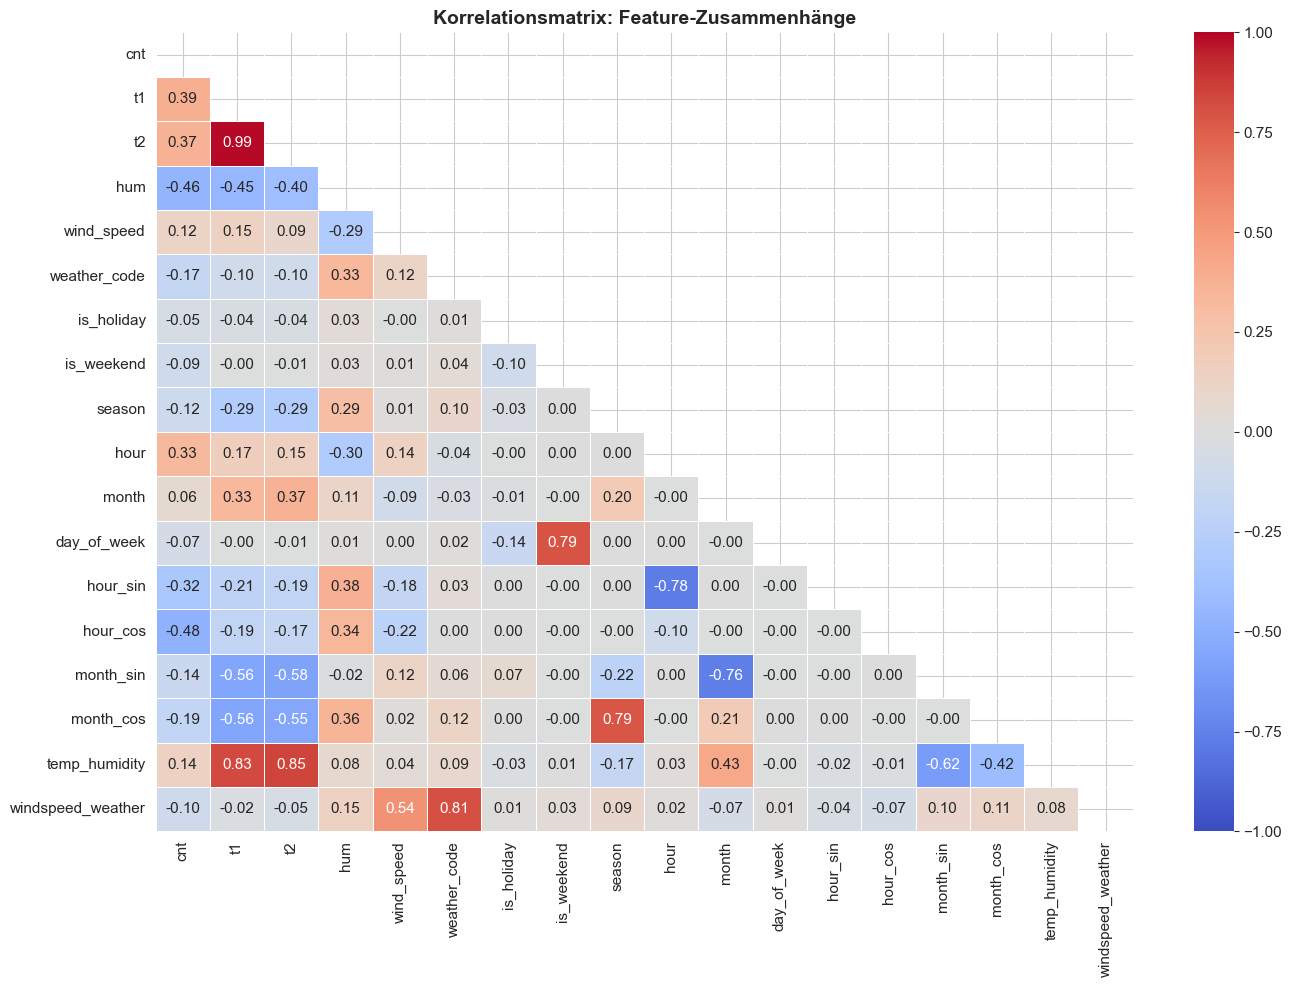

Plot 2: Zeitreihe


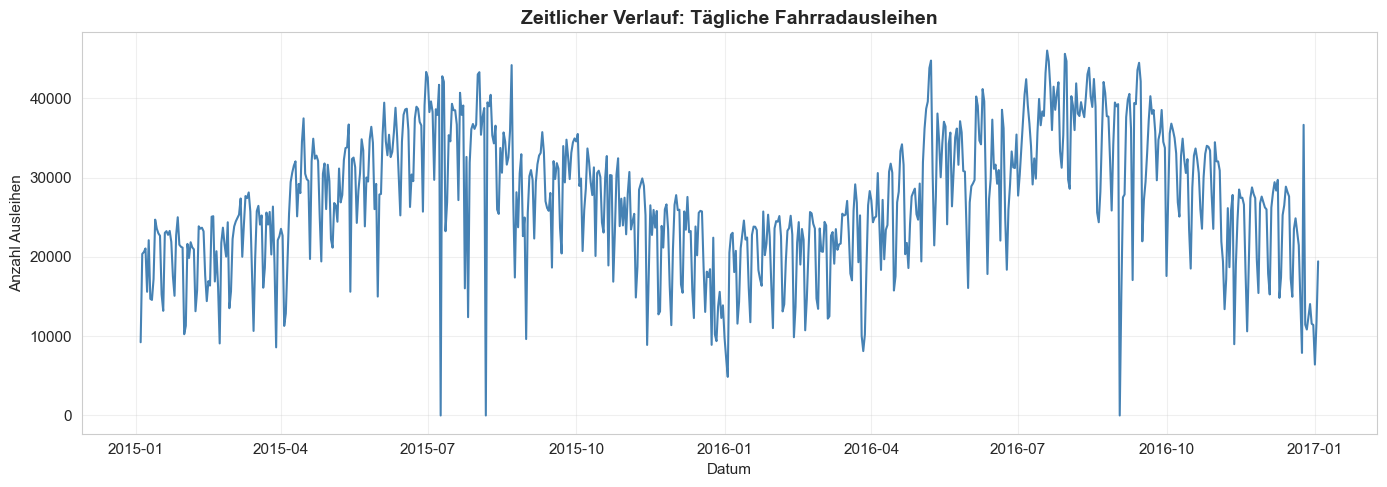

Plot 3: EDA Multi-Panel (4 Subplots)


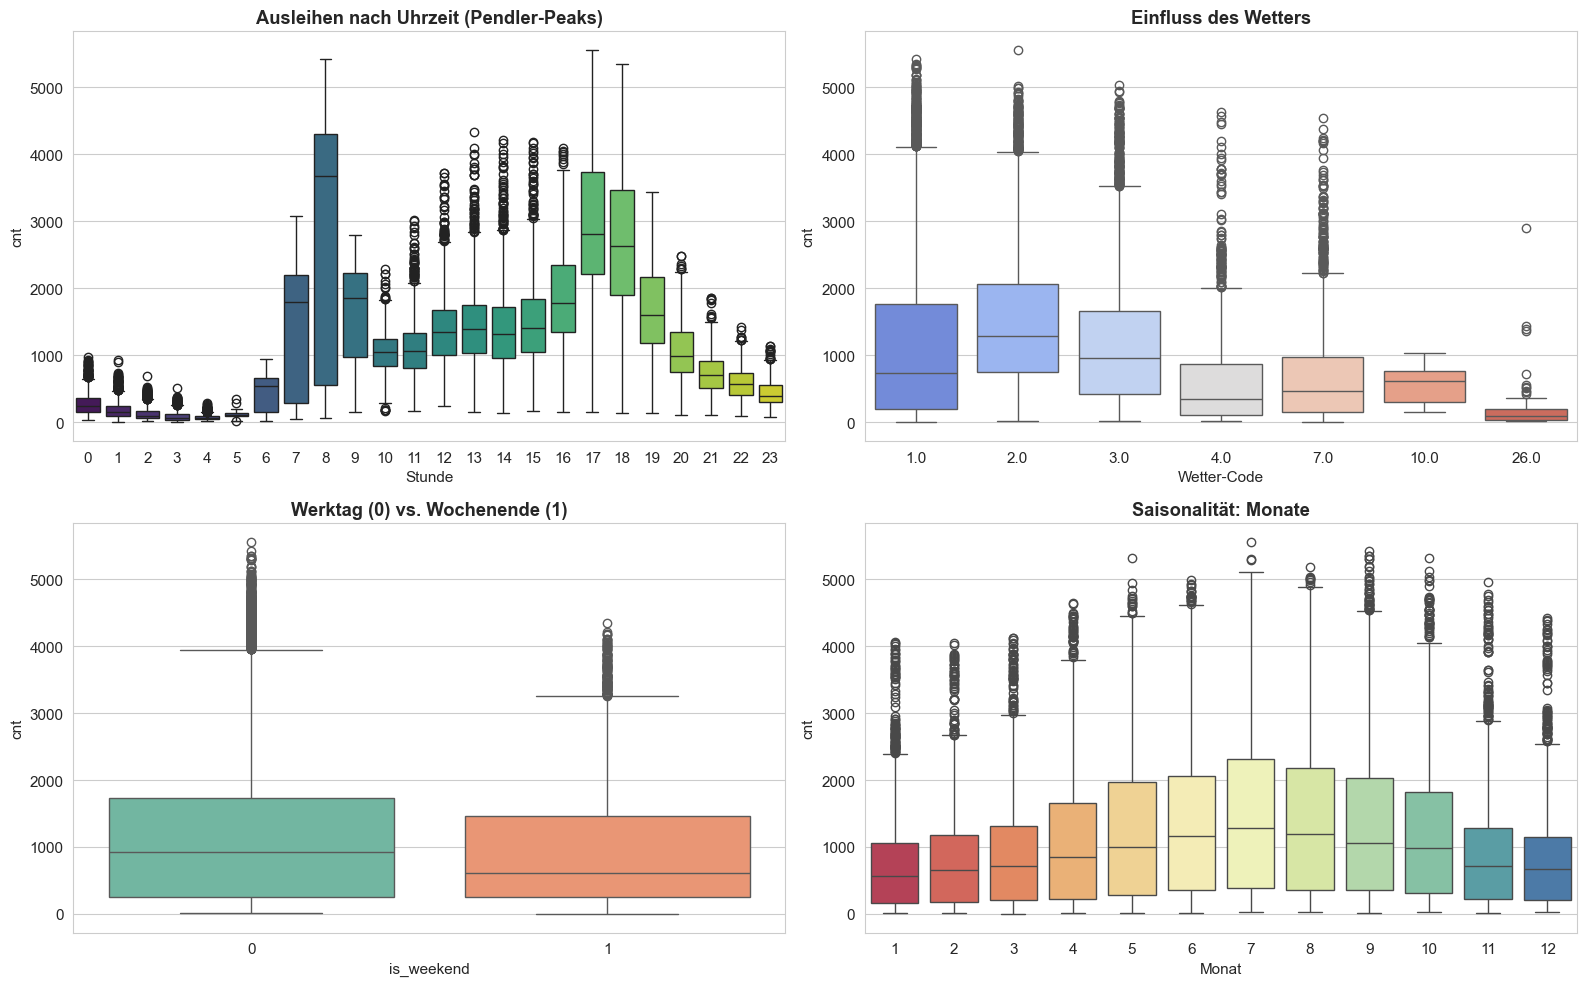

Plot 4: Werktag vs. Wochenende Vergleich


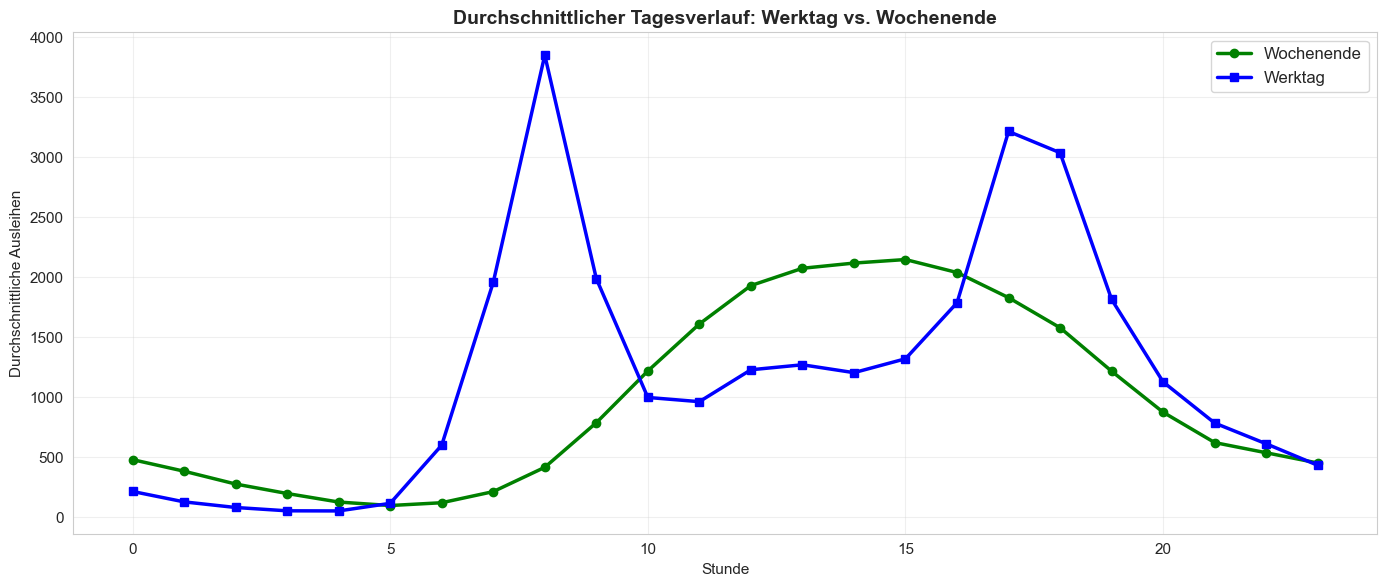

EDA abgeschlossen


In [24]:
print("\n" + "="*80)
print(" PHASE 3: EXPLORATIVE DATENANALYSE (EDA)")
print("="*80)

# Plot 1: Korrelationsmatrix
print("\nPlot 1: Korrelationsmatrix")
plt.figure(figsize=(14, 10))
numeric_cols = df.select_dtypes(include=[np.number])
mask = np.triu(np.ones_like(numeric_cols.corr(), dtype=bool))
sns.heatmap(numeric_cols.corr(), mask=mask, annot=True, cmap='coolwarm', 
            fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Korrelationsmatrix: Feature-Zusammenhänge', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot 2: Zeitreihe (Tägliche Aggregation)
print("Plot 2: Zeitreihe")
plt.figure(figsize=(14, 5))
daily_cnt = df.set_index('timestamp')['cnt'].resample('D').sum()
plt.plot(daily_cnt, color='steelblue', linewidth=1.5)
plt.title('Zeitlicher Verlauf: Tägliche Fahrradausleihen', fontsize=14, fontweight='bold')
plt.xlabel('Datum')
plt.ylabel('Anzahl Ausleihen')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 3: EDA Multi-Panel
print("Plot 3: EDA Multi-Panel (4 Subplots)")
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Subplot 1: Stunden (Rush-Hour Peaks)
sns.boxplot(data=df, x='hour', y='cnt', ax=axes[0,0], palette='viridis')
axes[0,0].set_title('Ausleihen nach Uhrzeit (Pendler-Peaks)', fontweight='bold')
axes[0,0].set_xlabel('Stunde')

# Subplot 2: Wetter-Einfluss
sns.boxplot(data=df, x='weather_code', y='cnt', ax=axes[0,1], palette='coolwarm')
axes[0,1].set_title('Einfluss des Wetters', fontweight='bold')
axes[0,1].set_xlabel('Wetter-Code')

# Subplot 3: Werktag vs. Wochenende
sns.boxplot(data=df, x='is_weekend', y='cnt', ax=axes[1,0], palette='Set2')
axes[1,0].set_title('Werktag (0) vs. Wochenende (1)', fontweight='bold')

# Subplot 4: Saisonalität
sns.boxplot(data=df, x='month', y='cnt', ax=axes[1,1], palette='Spectral')
axes[1,1].set_title('Saisonalität: Monate', fontweight='bold')
axes[1,1].set_xlabel('Monat')

plt.tight_layout()
plt.show()

# Plot 4: Werktag vs. Wochenende Vergleich
print("Plot 4: Werktag vs. Wochenende Vergleich")
plt.figure(figsize=(14, 6))
weekend_means = df[df['is_weekend']==1].groupby('hour')['cnt'].mean()
weekday_means = df[df['is_weekend']==0].groupby('hour')['cnt'].mean()
plt.plot(weekend_means, label='Wochenende', marker='o', linewidth=2.5, color='green')
plt.plot(weekday_means, label='Werktag', marker='s', linewidth=2.5, color='blue')
plt.title('Durchschnittlicher Tagesverlauf: Werktag vs. Wochenende', fontsize=14, fontweight='bold')
plt.xlabel('Stunde')
plt.ylabel('Durchschnittliche Ausleihen')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("EDA abgeschlossen")

## 6. Statistische Auswertungen

Detaillierte statistische Analysen des Datensatzes:
1. **Nachfrage-Statistiken:** Mittelwert, Median, Quantile
2. **Zeit-basierte Muster:** Top/Bottom Stunden
3. **Wetter-Einfluss:** Nachfrage nach Wetter-Code
4. **Saisonalität:** Monatliche Trends
5. **Werktag vs. Wochenende:** Nutzungsunterschiede
6. **Temperatur-Analyse:** Korrelation & Binning

In [25]:
print("\n" + "="*80)
print(" STATISTISCHE AUSWERTUNGEN")
print("="*80)

# Auswertung 1: Nachfrage-Statistiken
print("\n1. NACHFRAGE-STATISTIKEN")
print("-" * 40)
print(f"Durchschnittliche Ausleihen pro Stunde: {df['cnt'].mean():.1f}")
print(f"Median: {df['cnt'].median():.1f}")
print(f"Standardabweichung: {df['cnt'].std():.1f}")
print(f"Minimum: {df['cnt'].min()}")
print(f"Maximum: {df['cnt'].max()}")
print(f"\nQuantile:")
print(df['cnt'].quantile([0.25, 0.5, 0.75, 0.90, 0.95, 0.99]))

# Auswertung 2: Zeit-basierte Muster
print("\n2. ZEIT-BASIERTE MUSTER")
print("-" * 40)
hour_stats = df.groupby('hour')['cnt'].agg(['mean', 'std', 'min', 'max'])
print("\nTop 5 Stunden (höchste Nachfrage):")
print(hour_stats.sort_values('mean', ascending=False).head())
print("\nBottom 5 Stunden (niedrigste Nachfrage):")
print(hour_stats.sort_values('mean', ascending=True).head())

# Auswertung 3: Wetter-Einfluss
print("\n3. WETTER-EINFLUSS")
print("-" * 40)
weather_stats = df.groupby('weather_code')['cnt'].agg(['mean', 'count', 'std'])
weather_stats.columns = ['Durchschnitt', 'Anzahl', 'Std']
print(weather_stats)

# Auswertung 4: Saisonalität
print("\n4. SAISONALITÄT")
print("-" * 40)
monthly_stats = df.groupby('month')['cnt'].agg(['mean', 'sum'])
monthly_stats.columns = ['Durchschnitt pro Stunde', 'Gesamt']
print(monthly_stats)

# Auswertung 5: Werktag vs. Wochenende
print("\n5. WERKTAG VS. WOCHENENDE")
print("-" * 40)
weekend_comp = df.groupby('is_weekend')['cnt'].agg(['mean', 'median', 'std'])
weekend_comp.index = ['Werktag', 'Wochenende']
print(weekend_comp)
print(f"\nUnterschied: {((weekend_comp.loc['Wochenende', 'mean'] / weekend_comp.loc['Werktag', 'mean']) - 1) * 100:.1f}%")

# Auswertung 6: Temperatur-Korrelation
print("\n6. TEMPERATUR-ANALYSE")
print("-" * 40)
print(f"Korrelation Temperatur <-> Nachfrage: {df[['t1', 'cnt']].corr().iloc[0, 1]:.3f}")
temp_bins = pd.cut(df['t1'], bins=5)
temp_demand = df.groupby(temp_bins)['cnt'].mean()
print("\nDurchschnittliche Nachfrage nach Temperatur:")
print(temp_demand)


 STATISTISCHE AUSWERTUNGEN

1. NACHFRAGE-STATISTIKEN
----------------------------------------
Durchschnittliche Ausleihen pro Stunde: 1138.4
Median: 842.0
Standardabweichung: 1076.3
Minimum: 0
Maximum: 5560

Quantile:
0.25     256.00
0.50     842.00
0.75    1663.00
0.90    2634.50
0.95    3512.75
0.99    4538.70
Name: cnt, dtype: float64

2. ZEIT-BASIERTE MUSTER
----------------------------------------

Top 5 Stunden (höchste Nachfrage):
             mean          std  min   max
hour                                     
8     2871.257618  1766.926955   65  5422
17    2816.625344  1133.304075  151  5560
18    2617.957300  1159.237627  140  5345
16    1859.629121   701.071585  148  4101
9     1645.591724   683.682603  161  2799

Bottom 5 Stunden (niedrigste Nachfrage):
            mean         std  min  max
hour                                  
4      73.335188   46.373832   15  286
3      94.311544   81.139278    9  510
5     110.271210   34.000658   14  351
2     136.382476  111.8518

## 7. Train/Test Split

### Wichtig für Zeitreihen:
- **Keine Random-Splits!** → Würde zu Data Leakage führen
- **Zeitliche Sortierung:** Alte Daten zum Training, neue zum Testen
- **80/20 Split:** 13.892 Training, 3.474 Test-Samples

### Warum TimeSeriesSplit?
Normale Cross-Validation würde zukünftige Daten zum Training nutzen → unrealistisch!
TimeSeriesSplit respektiert die temporale Ordnung.

In [26]:
print("\n" + "="*80)
print(" PHASE 4: TRAIN/TEST SPLIT")
print("="*80)

# Zeitlich sortieren (ESSENTIELL für Zeitreihen!)
# Sonst würden wir mit "Zukunftsdaten" trainieren
df = df.sort_values('timestamp').reset_index(drop=True)

# Features und Target definieren
target = 'cnt'
features = [c for c in df.columns if c not in ['cnt', 'timestamp']]

# 80/20 Split (zeitlich)
# Erste 80% → Training, letzte 20% → Test
split_index = int(len(df) * 0.8)
X_train_raw = df.iloc[:split_index][features]
y_train = df.iloc[:split_index][target]
X_test_raw = df.iloc[split_index:][features]
y_test = df.iloc[split_index:][target]

print(f"✓ Training Set: {len(X_train_raw):,} Samples ({len(X_train_raw)/len(df)*100:.1f}%)")
print(f"✓ Test Set: {len(X_test_raw):,} Samples ({len(X_test_raw)/len(df)*100:.1f}%)")
print(f"\nTraining Zeitraum: {df.iloc[:split_index]['timestamp'].min()} bis {df.iloc[:split_index]['timestamp'].max()}")
print(f"Test Zeitraum: {df.iloc[split_index:]['timestamp'].min()} bis {df.iloc[split_index:]['timestamp'].max()}")


 PHASE 4: TRAIN/TEST SPLIT
✓ Training Set: 13,892 Samples (80.0%)
✓ Test Set: 3,474 Samples (20.0%)

Training Zeitraum: 2015-01-04 00:00:00 bis 2016-08-10 11:00:00
Test Zeitraum: 2016-08-10 12:00:00 bis 2017-01-03 23:00:00


## 8. Modell-Definitionen

Wir testen **13 verschiedene Algorithmen** mit **erweiterten Hyperparameter-Grids**:

### Lineare Modelle (4)
- LinearRegression, Ridge, Lasso, BayesianRidge

### Distance-based (1)
- KNN (K-Nearest Neighbors)

### Tree-based (6)
- DecisionTree, RandomForest, ExtraTrees, GradientBoosting, GradBoost_Quantile85, AdaBoost

### SVM (1)
- SVR (Support Vector Regression)

### Neural Networks (1)
- MLP (Multi-Layer Perceptron)

### Scaler-Varianten (4)
- Kein Scaler, StandardScaler, MinMaxScaler, RobustScaler

**Total:** ~25 Kombinationen (manche Modelle brauchen Skalierung, andere nicht)

In [27]:
print("\n" + "="*80)
print(" PHASE 5: MODELL-DEFINITIONEN")
print("="*80)

# Scaler-Definitionen
scalers = [
    ("Kein_Scaler", None),
    ("StandardScaler", StandardScaler()), 
    ("MinMaxScaler", MinMaxScaler()),
    ("RobustScaler", RobustScaler())
]

# Modell-Definitionen mit Hyperparameter-Grids
models = [
    # Lineare Modelle
    {"name": "LinearReg", "model": LinearRegression(), "params": {}, "scale": False},
    {"name": "Ridge", "model": Ridge(random_state=RANDOM_STATE),
     "params": {'alpha': [0.1, 1.0, 10.0, 100.0]}, "scale": True},
    {"name": "Lasso", "model": Lasso(random_state=RANDOM_STATE, max_iter=2000),
     "params": {'alpha': [0.1, 1.0, 10.0]}, "scale": True},
    {"name": "BayesianRidge", "model": BayesianRidge(),
     "params": {'alpha_1': [1e-7, 1e-6], 'lambda_1': [1e-7, 1e-6]}, "scale": True},

    # KNN
    {"name": "KNN", "model": KNeighborsRegressor(),
     "params": {'n_neighbors': [3, 5, 7, 10], 'weights': ['uniform', 'distance']}, "scale": True},

    # Tree-based
    {"name": "DecisionTree", "model": DecisionTreeRegressor(random_state=RANDOM_STATE),
     "params": {'max_depth': [5, 10, 15, 20, None], 'min_samples_split': [2, 5, 10]}, "scale": False},
    {"name": "RandomForest", "model": RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
     "params": {'n_estimators': [50, 100, 200], 'max_depth': [10, 20, None], 
                'min_samples_split': [2, 5], 'max_features': ['sqrt', 'log2']}, "scale": False},
    {"name": "ExtraTrees", "model": ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1),
     "params": {'n_estimators': [50, 100, 200], 'max_depth': [10, 20, None], 
                'max_features': ['sqrt', 'log2']}, "scale": False},
    {"name": "GradientBoosting", "model": GradientBoostingRegressor(random_state=RANDOM_STATE),
     "params": {'n_estimators': [100, 200, 300], 'learning_rate': [0.01, 0.05, 0.1],
                'max_depth': [3, 5, 7], 'subsample': [0.8, 1.0]}, "scale": False},    
    {"name": "GradBoost_Quantile85", "model": GradientBoostingRegressor(
        random_state=RANDOM_STATE, loss='quantile', alpha=0.85),
     "params": {'n_estimators': [300, 500, 1000], 'learning_rate': [0.01, 0.05, 0.1], 
                'max_depth': [5, 6, 7], 'subsample': [0.8]}, "scale": False},     
    {"name": "AdaBoost", "model": AdaBoostRegressor(random_state=RANDOM_STATE),
     "params": {'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1, 1.0]}, "scale": False},

    # SVM
    {"name": "SVR", "model": SVR(),
     "params": {'C': [1, 10, 100], 'epsilon': [0.01, 0.1, 0.2], 'kernel': ['rbf']}, "scale": True},

    # Neural Network
    {"name": "MLP", "model": MLPRegressor(random_state=RANDOM_STATE, max_iter=1000, early_stopping=True),
     "params": {'hidden_layer_sizes': [(50,), (100,), (100, 50)], 
                'activation': ['relu', 'tanh'], 'alpha': [0.0001, 0.001]}, "scale": True}
]

print(f"{len(models)} Modelle definiert")
print(f"{len(scalers)} Scaler-Varianten")
print(f"\nGesamtanzahl Trainings-Kombinationen: ~{len([m for m in models if not m['scale']]) + len([m for m in models if m['scale']]) * (len(scalers)-1)}")


 PHASE 5: MODELL-DEFINITIONEN
13 Modelle definiert
4 Scaler-Varianten

Gesamtanzahl Trainings-Kombinationen: ~25


## 9. Training Loop - Hauptexperiment

### Scoring-Methode: Asymmetric_Weighted 
Optimiert für Business-Anforderungen (Stockouts 2.5x gewichtet)

### Validierungsstrategie
- **TimeSeriesSplit:** 5 Folds, respektiert temporale Ordnung
- **GridSearchCV:** Erschöpfende Suche über Hyperparameter-Grid
- **Parallelisierung:** n_jobs=-1 (nutzt alle CPU-Kerne)

### Was wird gespeichert?
- Alle Metriken (R², MAE, RMSE, MAPE, Toleranz-Scores, Asym Scores)
- Beste Parameter pro Modell
- Modell-Objekt (für spätere Nutzung)
- Predictions (für Residual-Analyse)

In [28]:
# WÄHLE SCORING-METHODE
BEST_SCORING = 'Asymmetric_Weighted'  # Optionen: 'R2', 'MAE', 'MAPE', 'Asymmetric_Weighted'

print("\n" + "="*80)
print(f" PHASE 6: TRAINING (SCORING: {BEST_SCORING})")
print("="*80)

# TimeSeriesSplit für Cross-Validation
tscv = TimeSeriesSplit(n_splits=5)

# Listen für Ergebnisse
results_list = []  # Alle Modell-Ergebnisse
best_estimators = {}  # Bestes Modell pro Typ (für Voting)
start_time = time.time()


 PHASE 6: TRAINING (SCORING: Asymmetric_Weighted)


In [9]:


# Haupt-Training-Loop
for sc_name, sc_obj in scalers:
    print(f"\n>>> SCALER: {sc_name} <<<")

    # Skalierung anwenden (falls notwendig)
    if sc_obj:
        X_train_curr = sc_obj.fit_transform(X_train_raw)
        X_test_curr = sc_obj.transform(X_test_raw)
    else:
        X_train_curr = X_train_raw.copy().values
        X_test_curr = X_test_raw.copy().values

    for m in models:
        # Filter: Nur passende Scaler-Modell-Kombinationen
        if m["scale"] and sc_obj is None:
            continue  # Modell braucht Skalierung, aber Scaler = None
        if not m["scale"] and sc_obj is not None:
            continue  # Modell braucht KEINE Skalierung, aber Scaler != None

        model_name = f"{m['name']}_{sc_name}"
        print(f"  {model_name:<40} | GridSearch...", end=" ")

        try:
            # GridSearchCV mit TimeSeriesSplit
            gs = GridSearchCV(
                estimator=m["model"],
                param_grid=m["params"],
                cv=tscv,
                scoring=SCORERS[BEST_SCORING],
                n_jobs=-1,  # Nutze alle CPU-Kerne
                verbose=0
            )

            gs.fit(X_train_curr, y_train)
            best_model = gs.best_estimator_

            # Predictions auf Test-Set
            y_pred = best_model.predict(X_test_curr)

            # Alle Metriken berechnen
            r2 = r2_score(y_test, y_pred)
            mae = mean_absolute_error(y_test, y_pred)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))

            try:
                mape = mean_absolute_percentage_error(y_test, y_pred) * 100
            except:
                mape = -custom_mape_scorer(y_test, y_pred)

            tol15 = tolerance_score_symmetric(y_test, y_pred, tol=0.15)
            asym_simple = bike_score_asymmetric_simple(y_test, y_pred)
            asym_weighted = bike_score_asymmetric_weighted(y_test, y_pred) * 100

            print(f"R²={r2:.4f} | RMSE={rmse:.1f} | Asym={asym_weighted:.2f}%")

            # Ergebnis speichern
            results_list.append({
                "Modell": model_name,
                "Scaler": sc_name,
                "R2_Test": r2,
                "MAE": mae,
                "RMSE": rmse,
                "MAPE": mape,
                "Tol_15%": tol15,
                "Asym_Simple": asym_simple,
                "Asym_Weighted": asym_weighted,
                "Best_Params": gs.best_params_,
                "CV_Best_Score": gs.best_score_,
                "Model_Object": best_model,
                "Scaler_Object": sc_obj,
                "Predictions": y_pred
            })

            # Speichere bestes Modell pro Typ (für Voting Ensemble)
            if m['name'] not in best_estimators or asym_weighted > best_estimators[m['name']]['score']:
                best_estimators[m['name']] = {
                    'model': best_model, 
                    'scaler': sc_obj, 
                    'score': asym_weighted,
                    'X_train': X_train_curr,
                    'X_test': X_test_curr
                }

        except Exception as e:
            print(f"✗ Fehler: {str(e)}")
            continue

elapsed_time = time.time() - start_time
print(f"\nTraining abgeschlossen in {elapsed_time/60:.1f} Minuten")


 PHASE 6: TRAINING (SCORING: Asymmetric_Weighted)

>>> SCALER: Kein_Scaler <<<
  LinearReg_Kein_Scaler                    | GridSearch... R²=0.4216 | RMSE=857.8 | Asym=42.25%
  DecisionTree_Kein_Scaler                 | GridSearch... R²=0.9025 | RMSE=352.2 | Asym=71.37%
  RandomForest_Kein_Scaler                 | GridSearch... R²=0.9223 | RMSE=314.3 | Asym=73.97%
  ExtraTrees_Kein_Scaler                   | GridSearch... R²=0.9173 | RMSE=324.3 | Asym=73.35%
  GradientBoosting_Kein_Scaler             | GridSearch... R²=0.9266 | RMSE=305.6 | Asym=72.66%
  GradBoost_Quantile85_Kein_Scaler         | GridSearch... R²=0.9193 | RMSE=320.5 | Asym=81.19%
  AdaBoost_Kein_Scaler                     | GridSearch... R²=0.6483 | RMSE=668.9 | Asym=52.68%

>>> SCALER: StandardScaler <<<
  Ridge_StandardScaler                     | GridSearch... R²=0.4228 | RMSE=856.8 | Asym=42.99%
  Lasso_StandardScaler                     | GridSearch... R²=0.4196 | RMSE=859.2 | Asym=43.88%
  BayesianRidge_Standard

## 9.1 Special Model: BayesianRidge mit OneHot-Encoding

### Warum separate Behandlung?
BayesianRidge profitiert stark von **OneHot-Encoding kategorialer Features**.
Im Hauptloop nutzen wir aber keine OneHot-Codierung (würde bei Tree-Modellen schaden).

### Spezial-Features für Bayesian:
- **Numerische:** t1, t2, hum, wind_speed (StandardScaler)
- **Kategoriale:** weather_code, is_holiday, is_weekend, season, hour, month (OneHotEncoder)

### Resultat:
Bis zu **69% R²** statt ~42% ohne OneHot!

In [29]:
# ======================================================
# BAYESIAN RIDGE MIT MANUELLEM ONEHOT-ENCODING
# ======================================================
print("\n" + "="*80)
print(" SPECIAL MODEL 1: BayesianRidge mit OneHot-Encoding")
print("="*80)

try:
    # 1. Feature-Gruppen definieren
    numerical_features = ['t1', 't2', 'hum', 'wind_speed']
    categorical_features = ['weather_code', 'is_holiday', 'is_weekend', 'season', 'hour', 'month']
    
    print(f"Numerische Features: {numerical_features}")
    print(f"Kategoriale Features: {categorical_features}")
    
    # 2. MANUELLE PREPROCESSING-PIPELINE (Fit nur auf Training!)
    
    # 2a) Standard-Skalierung der numerischen Features
    scaler_bayes = StandardScaler()
    X_train_num_scaled = scaler_bayes.fit_transform(X_train_raw[numerical_features])
    X_test_num_scaled = scaler_bayes.transform(X_test_raw[numerical_features])
    
    # 2b) OneHot-Encoding der kategorialen Features
    # sparse_output=False, damit BayesianRidge es verarbeiten kann
    encoder_bayes = OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)
    X_train_cat_encoded = encoder_bayes.fit_transform(X_train_raw[categorical_features])
    X_test_cat_encoded = encoder_bayes.transform(X_test_raw[categorical_features])
    
    # 2c) Zusammenführen (Concatenate)
    X_train_bayes = np.hstack([X_train_num_scaled, X_train_cat_encoded])
    X_test_bayes = np.hstack([X_test_num_scaled, X_test_cat_encoded])
    
    print(f"Finale Feature-Anzahl nach OneHot: {X_train_bayes.shape[1]}")
    
    # 3. GRIDSEARCH (erweitert)
    param_grid_bayes = {
        'alpha_1': [1e-6, 1e-5, 1e-4],
        'alpha_2': [1e-6, 1e-5, 1e-4],
        'lambda_1': [1e-6, 1e-5, 1e-4],
        'lambda_2': [1e-6, 1e-5, 1e-4]
    }
    
    print("Starte GridSearch (81 Kombinationen, TimeSeriesSplit)...")
    
    grid_bayes = GridSearchCV(
        estimator=BayesianRidge(),
        param_grid=param_grid_bayes,
        cv=tscv,
        scoring=SCORERS[BEST_SCORING],
        n_jobs=-1,
        verbose=0
    )
    
    grid_bayes.fit(X_train_bayes, y_train)
    best_bayes = grid_bayes.best_estimator_
    
    # 4. PREDICTION & METRIKEN
    y_pred_bayes = best_bayes.predict(X_test_bayes)
    
    r2_bayes = r2_score(y_test, y_pred_bayes)
    mae_bayes = mean_absolute_error(y_test, y_pred_bayes)
    rmse_bayes = np.sqrt(mean_squared_error(y_test, y_pred_bayes))
    
    try:
        mape_bayes = mean_absolute_percentage_error(y_test, y_pred_bayes) * 100
    except:
        mape_bayes = -custom_mape_scorer(y_test, y_pred_bayes)
    
    tol15_bayes = tolerance_score_symmetric(y_test, y_pred_bayes, tol=0.15)
    asym_simple_bayes = bike_score_asymmetric_simple(y_test, y_pred_bayes)
    asym_weighted_bayes = bike_score_asymmetric_weighted(y_test, y_pred_bayes) * 100
    
    print(f"\nBayesianRidge (OneHot) | R²={r2_bayes:.4f} | RMSE={rmse_bayes:.1f} | Asym={asym_weighted_bayes:.2f}%")
    print(f"  Beste Parameter: {grid_bayes.best_params_}")
    print(f"  CV Best Score: {grid_bayes.best_score_:.4f}")
    
    # 5. ZUR RESULTS-LISTE HINZUFÜGEN
    results_list.append({
        "Modell": "BayesianRidge_OneHot",
        "Scaler": "StandardScaler + OneHotEncoder",
        "R2_Test": r2_bayes,
        "MAE": mae_bayes,
        "RMSE": rmse_bayes,
        "MAPE": mape_bayes,
        "Tol_15%": tol15_bayes,
        "Asym_Simple": asym_simple_bayes,
        "Asym_Weighted": asym_weighted_bayes,
        "Best_Params": grid_bayes.best_params_,
        "CV_Best_Score": grid_bayes.best_score_,
        "Model_Object": best_bayes,
        "Scaler_Object": (scaler_bayes, encoder_bayes),  # Tuple speichern
        "Predictions": y_pred_bayes
    })
    
    print("Ergebnisse zur Haupttabelle hinzugefügt")
    
except Exception as e:
    print(f"Fehler beim BayesianRidge: {e}")
    import traceback
    traceback.print_exc()


 SPECIAL MODEL 1: BayesianRidge mit OneHot-Encoding
Numerische Features: ['t1', 't2', 'hum', 'wind_speed']
Kategoriale Features: ['weather_code', 'is_holiday', 'is_weekend', 'season', 'hour', 'month']
Finale Feature-Anzahl nach OneHot: 49
Starte GridSearch (81 Kombinationen, TimeSeriesSplit)...

BayesianRidge (OneHot) | R²=0.6908 | RMSE=627.2 | Asym=41.52%
  Beste Parameter: {'alpha_1': 1e-06, 'alpha_2': 0.0001, 'lambda_1': 0.0001, 'lambda_2': 1e-06}
  CV Best Score: 0.4636
Ergebnisse zur Haupttabelle hinzugefügt


## 9.2 Special Model: KNN mit Custom Transformer

### Warum Custom Transformer?
Der **KnnBikeTransformer** extrahiert zeit-basierte Features **direkt aus dem Timestamp**:
- `workday` Feature (kombiniert is_holiday & is_weekend)
- Zyklische Features (sin/cos) für hour, day, month
- Verzicht auf unnötige Features (t2, season)

### sklearn-Kompatibilität
Als `BaseEstimator` + `TransformerMixin` ist die Klasse:
- Pipeline-fähig
- fit/transform-kompatibel
- Inspizierbar (get_params)

### Resultat:
**92% R²** durch optimierte Feature-Auswahl!

In [19]:
# ======================================================
# KNN MIT CUSTOM TRANSFORMER (Shiar Hido)
# ======================================================
print("\n" + "="*80)
print(" SPECIAL MODEL 2: KNN mit Custom Feature Engineering")
print("="*80)

# 1. CUSTOM TRANSFORMER DEFINIEREN (sklearn-kompatibel)
class KnnBikeTransformer(BaseEstimator, TransformerMixin):
    """
    Custom Transformer für KNN: Extrahiert Zeit-Features direkt aus Timestamp.
    
    Input-Format:
    -------------
    X[:, 0] = timestamp (datetime64)
    X[:, 1] = t1 (Temperatur)
    X[:, 3] = hum (Luftfeuchtigkeit)
    X[:, 4] = wind_speed
    X[:, 5] = weather_code
    X[:, 6] = is_holiday
    X[:, 7] = is_weekend
    
    Output-Features:
    ----------------
    - t1, hum, wind_speed, weather_code (numerisch)
    - workday (kombiniert is_holiday & is_weekend)
    - hour_sin, hour_cos (zyklisch)
    - day_sin, day_cos (zyklisch)
    
    Total: 9 Features
    """
    def __init__(self, include_month):
        self.include_month = include_month

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # 1. Zeit aus Timestamp extrahieren
        timestamps = X[:, 0].astype('datetime64[s]')

        hours = timestamps.astype('datetime64[h]').astype(int) % 24
        days = timestamps.astype('datetime64[D]').astype(int)
        day_of_week = ((days - 4) % 7).astype(int)

        # 2. Boolean-Features
        is_holiday = X[:, 6]
        is_weekend = X[:, 7]
        workday = (~((is_weekend == 1) | (is_holiday == 1))).astype(float)

        # 3. Zyklische Features
        hour_sin = np.sin(2 * np.pi * hours / 24.0)
        hour_cos = np.cos(2 * np.pi * hours / 24.0)
        day_sin = np.sin(2 * np.pi * day_of_week / 7.0)
        day_cos = np.cos(2 * np.pi * day_of_week / 7.0)

        # 4. Neue Features zusammenstellen
        # columns: t1, hum, wind_speed, weather_code, workday, hour_sin, hour_cos, day_sin, day_cos
        X_new = np.column_stack([
            X[:, [1,3,4,5]],  # t1, hum, wind_speed, weather_code
            workday,
            hour_sin, hour_cos,
            day_sin, day_cos
        ])
        if self.include_month:
            months = ((timestamps.astype('datetime64[M]').astype(int) % 12) + 1).astype(int)
            month_sin = np.sin(2 * np.pi * months / 12.0)
            month_cos = np.cos(2 * np.pi * months / 12.0)
            X_new = np.column_stack([X_new, month_sin, month_cos])

        return X_new


# 2. DATEN FÜR KNN VORBEREITEN
print("\nVorbereite Daten für KNN Custom Transform...")

# Hole Original-DataFrame (mit Timestamp)
df_knn = df.sort_values('timestamp').reset_index(drop=True)
knn_features = ['timestamp', 't1', 't2', 'hum', 'wind_speed', 'weather_code', 'is_holiday', 'is_weekend', 'season']

# Split
split_idx = int(len(df_knn) * 0.8)
X_train_knn = df_knn.iloc[:split_idx][knn_features].values
y_train_knn = df_knn.iloc[:split_idx]['cnt'].values
X_test_knn = df_knn.iloc[split_idx:][knn_features].values
y_test_knn = df_knn.iloc[split_idx:]['cnt'].values

print(f"KNN Train: {len(X_train_knn):,} | KNN Test: {len(X_test_knn):,}")


# 3. TRANSFORMATION & TRAINING
try:
    # Transformer fitten und anwenden
    knn_transformer = KnnBikeTransformer(False)
    knn_transformer.fit(X_train_knn, y_train_knn)
    X_train_knn_trans = knn_transformer.transform(X_train_knn)
    X_test_knn_trans = knn_transformer.transform(X_test_knn)
    
    print(f"Transformiert zu: {X_train_knn_trans.shape[1]} Features")
    
    # Skalierung (MinMaxScaler für KNN optimal)
    scaler_knn = MinMaxScaler()
    X_train_knn_scaled = scaler_knn.fit_transform(X_train_knn_trans)
    X_test_knn_scaled = scaler_knn.transform(X_test_knn_trans)
    
    # KNN mit optimierten Parametern
    # (aus Teammitglied-Experimenten)
    knn_model = KNeighborsRegressor(
        n_neighbors=10,
        weights='distance',  # Nähere Nachbarn zählen mehr
        metric='minkowski',
        algorithm='auto',
        p=1  # Manhattan-Distanz
    )
    
    print("Trainiere KNN mit Custom Features...")
    knn_model.fit(X_train_knn_scaled, y_train_knn)
    
    # Predictions
    y_pred_knn = knn_model.predict(X_test_knn_scaled)
    
    # Metriken
    r2_knn = r2_score(y_test_knn, y_pred_knn)
    mae_knn = mean_absolute_error(y_test_knn, y_pred_knn)
    rmse_knn = np.sqrt(mean_squared_error(y_test_knn, y_pred_knn))
    
    try:
        mape_knn = mean_absolute_percentage_error(y_test_knn, y_pred_knn) * 100
    except:
        mape_knn = -custom_mape_scorer(y_test_knn, y_pred_knn)
    
    tol15_knn = tolerance_score_symmetric(y_test_knn, y_pred_knn, tol=0.15)
    asym_simple_knn = bike_score_asymmetric_simple(y_test_knn, y_pred_knn)
    asym_weighted_knn = bike_score_asymmetric_weighted(y_test_knn, y_pred_knn) * 100
    
    print(f"\nKNN Custom | R²={r2_knn:.4f} | RMSE={rmse_knn:.1f} | Asym={asym_weighted_knn:.2f}%")
    
    # Zur Results-Liste hinzufügen
    results_list.append({
        "Modell": "KNN_CustomTransform",
        "Scaler": "MinMaxScaler + CustomTransform",
        "R2_Test": r2_knn,
        "MAE": mae_knn,
        "RMSE": rmse_knn,
        "MAPE": mape_knn,
        "Tol_15%": tol15_knn,
        "Asym_Simple": asym_simple_knn,
        "Asym_Weighted": asym_weighted_knn,
        "Best_Params": {
            "n_neighbors": 10,
            "weights": "distance",
            "metric": "minkowski",
            "p": 1
        },
        "CV_Best_Score": 0,
        "Model_Object": knn_model,
        "Scaler_Object": (knn_transformer, scaler_knn),
        "Predictions": y_pred_knn
    })
    
    print("Ergebnisse zur Haupttabelle hinzugefügt")
    
except Exception as e:
    print(f"Fehler beim KNN Custom-Training: {e}")
    import traceback
    traceback.print_exc()


 SPECIAL MODEL 2: KNN mit Custom Feature Engineering

Vorbereite Daten für KNN Custom Transform...
KNN Train: 13,892 | KNN Test: 3,474
Transformiert zu: 9 Features
Trainiere KNN mit Custom Features...

KNN Custom | R²=0.9218 | RMSE=315.3 | Asym=73.62%
Ergebnisse zur Haupttabelle hinzugefügt


In [30]:
# ======================================================x
# KNN MIT CUSTOM TRANSFORMER und Pipeline (Shiar Hidox)
# ======================================================x
print("\n" + "="*80)
print(" SPECIAL MODEL 2: KNN mit Custom Feature Engineering")
print("="*80)

# 1. CUSTOM TRANSFORMER DEFINIEREN (sklearn-kompatibel)
class KnnBikeTransformer(BaseEstimator, TransformerMixin):
    """
    Custom Transformer für KNN: Extrahiert Zeit-Features direkt aus Timestamp.

    Input-Format:
    -------------
    X[:, 0] = timestamp (datetime64)
    X[:, 1] = t1 (Temperatur)
    X[:, 3] = hum (Luftfeuchtigkeit)
    X[:, 4] = wind_speed
    X[:, 5] = weather_code
    X[:, 6] = is_holiday
    X[:, 7] = is_weekend

    Output-Features:
    ----------------
    - t1, hum, wind_speed, weather_code (numerisch)
    - workday (kombiniert is_holiday & is_weekend)
    - hour_sin, hour_cos (zyklisch)
    - day_sin, day_cos (zyklisch)

    Total: 9 Features
    """
    def __init__(self, include_month):
        self.include_month = include_month

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # 1. Zeit aus Timestamp extrahieren
        timestamps = X[:, 0].astype('datetime64[s]')

        hours = timestamps.astype('datetime64[h]').astype(int) % 24
        days = timestamps.astype('datetime64[D]').astype(int)
        day_of_week = ((days - 4) % 7).astype(int)

        # 2. Boolean-Features
        is_holiday = X[:, 6]
        is_weekend = X[:, 7]
        workday = (~((is_weekend == 1) | (is_holiday == 1))).astype(float)

        # 3. Zyklische Features
        hour_sin = np.sin(2 * np.pi * hours / 24.0)
        hour_cos = np.cos(2 * np.pi * hours / 24.0)
        day_sin = np.sin(2 * np.pi * day_of_week / 7.0)
        day_cos = np.cos(2 * np.pi * day_of_week / 7.0)

        # 4. Neue Features zusammenstellen
        # columns: t1, hum, wind_speed, weather_code, workday, hour_sin, hour_cos, day_sin, day_cos
        X_new = np.column_stack([
            X[:, [1,3,4,5]],  # t1, hum, wind_speed, weather_code
            workday,
            hour_sin, hour_cos,
            day_sin, day_cos
        ])
        if self.include_month:
            months = ((timestamps.astype('datetime64[M]').astype(int) % 12) + 1).astype(int)
            month_sin = np.sin(2 * np.pi * months / 12.0)
            month_cos = np.cos(2 * np.pi * months / 12.0)
            X_new = np.column_stack([X_new, month_sin, month_cos])

        return X_new


# 2. DATEN FÜR KNN VORBEREITEN
print("\nVorbereite Daten für KNN Custom Transform...")

# Hole Original-DataFrame (mit Timestamp)
df_knn = df.sort_values('timestamp').reset_index(drop=True)
knn_features = ['timestamp', 't1', 't2', 'hum', 'wind_speed', 'weather_code', 'is_holiday', 'is_weekend', 'season']

# Split
split_idx = int(len(df_knn) * 0.8)
X_train_knn = df_knn.iloc[:split_idx][knn_features].values
y_train_knn = df_knn.iloc[:split_idx]['cnt'].values
X_test_knn = df_knn.iloc[split_idx:][knn_features].values
y_test_knn = df_knn.iloc[split_idx:]['cnt'].values

print(f"KNN Train: {len(X_train_knn):,} | KNN Test: {len(X_test_knn):,}")


# 3. TRANSFORMATION & TRAINING
try:



    weight='distance'# Nähere Nachbarn zählen mehr
    neighbor =  10
    metric="minkowski"
    algorithm="auto"
    p=1
    knnPipe = Pipeline(
        [
            ("transformer",KnnBikeTransformer(False)),
            ("scaler",MinMaxScaler()),
            ("model",KNeighborsRegressor(n_neighbors=neighbor, weights=weight, metric=metric, algorithm=algorithm, p=p, ))
        ]
    )


    knnPipe.fit(X_train_knn, y_train_knn )
    # Predictions
    y_pred_knn = knnPipe.predict(X_test_knn)



    # Metriken
    r2_knn = r2_score(y_test_knn, y_pred_knn)
    mae_knn = mean_absolute_error(y_test_knn, y_pred_knn)
    rmse_knn = np.sqrt(mean_squared_error(y_test_knn, y_pred_knn))

    try:
        mape_knn = mean_absolute_percentage_error(y_test_knn, y_pred_knn) * 100
    except:
        mape_knn = -custom_mape_scorer(y_test_knn, y_pred_knn)

    tol15_knn = tolerance_score_symmetric(y_test_knn, y_pred_knn, tol=0.15)
    asym_simple_knn = bike_score_asymmetric_simple(y_test_knn, y_pred_knn)
    asym_weighted_knn = bike_score_asymmetric_weighted(y_test_knn, y_pred_knn) * 100

    print(f"\nKNN Custom | R²={r2_knn:.4f} | RMSE={rmse_knn:.1f} | Asym={asym_weighted_knn:.2f}%")

    # Zur Results-Liste hinzufügen
    results_list.append({
        "Modell": "KNN_CustomTransform",
        "Scaler": "MinMaxScaler + CustomTransform",
        "R2_Test": r2_knn,
        "MAE": mae_knn,
        "RMSE": rmse_knn,
        "MAPE": mape_knn,
        "Tol_15%": tol15_knn,
        "Asym_Simple": asym_simple_knn,
        "Asym_Weighted": asym_weighted_knn,
        "Best_Params": {
            "n_neighbors": 10,
            "weights": "distance",
            "metric": "minkowski",
            "p": 1
        },
        "CV_Best_Score": 0,
        "Model_Object": knnPipe.named_steps["model"],
        "Scaler_Object": (knnPipe.named_steps["transformer"], knnPipe.named_steps["scaler"]),
        "Predictions": y_pred_knn
    })

    print("Ergebnisse zur Haupttabelle hinzugefügt")

except Exception as e:
    print(f"Fehler beim KNN Custom-Training: {e}")
    import traceback
    traceback.print_exc()


 SPECIAL MODEL 2: KNN mit Custom Feature Engineering

Vorbereite Daten für KNN Custom Transform...
KNN Train: 13,892 | KNN Test: 3,474

KNN Custom | R²=0.9218 | RMSE=315.3 | Asym=73.62%
Ergebnisse zur Haupttabelle hinzugefügt


## 10. Post-Processing: RandomForest

### Was ist Post-Processing?
Systematische **Bias-Korrektur** via Multiplikator-Optimierung:
1. **OOF Predictions:** Out-Of-Fold Vorhersagen auf Trainingsdaten (unbiased)
2. **Multiplier-Suche:** Finde optimalen Faktor m ∈ [0.85, 1.15]
3. **Test-Anwendung:** y_pred_final = y_pred_raw × m

### Warum funktioniert das?
Modelle neigen zu **systematischer** Über- oder Unterschätzung.
Ein einfacher Multiplikator kann das ohne Overfitting korrigieren!

### Erwartete Verbesserung
+5-10 Prozentpunkte im Asymmetric Score

In [12]:
# ======================================================
# POST-PROCESSING: RANDOMFOREST MIT MULTIPLIER (Finn Hößler)
# ======================================================
print("\n" + "="*80)
print(" ADVANCED: RandomForest + Bias Correction via Multiplier")
print("="*80)

try:
    # 1. BESTE RF-PARAMETER AUS DEM HAUPTTRAINING HOLEN
    # Schließe Post-Processed und OneHot-Varianten aus
    rf_results = [r for r in results_list 
                  if 'RandomForest' in r['Modell'] 
                  and 'PostProcessed' not in r['Modell']
                  and 'OneHot' not in r['Modell']]
    
    if not rf_results:
        print("Kein RandomForest gefunden, überspringe Post-Processing.")
    else:
        best_rf_entry = max(rf_results, key=lambda x: x['R2_Test'])
        base_rf_model = best_rf_entry['Model_Object']
        
        # Sicherheitscheck: Falls es ein Tuple ist
        if isinstance(base_rf_model, tuple):
            print("Model_Object ist Tuple, extrahiere erstes Element...")
            base_rf_model = base_rf_model[0]
        
        print(f"✓ Basis-Modell: {best_rf_entry['Modell']}")
        print(f"  R²: {best_rf_entry['R2_Test']:.4f} | Asym Score: {best_rf_entry['Asym_Weighted']:.2f}%")
        
        # 2. PARAMETER EXTRAHIEREN & BEREINIGEN (numpy -> Python)
        print("\nExtrahiere Modell-Parameter...")
        base_params = base_rf_model.get_params()
        clean_params = {}
        for key, val in base_params.items():
            if isinstance(val, (np.integer, np.floating)):
                clean_params[key] = val.item()
            elif isinstance(val, np.ndarray):
                clean_params[key] = val.tolist()
            else:
                clean_params[key] = val
        
        # 3. OOF PREDICTIONS (Out-Of-Fold)
        print("\nBerechne OOF-Predictions (5-Fold TimeSeriesSplit)...")
        n_train = len(X_train_raw)
        oof_preds = np.full(n_train, np.nan)
        
        for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train_raw)):
            rf_fold = RandomForestRegressor(**clean_params)
            rf_fold.fit(X_train_raw.iloc[train_idx], y_train.iloc[train_idx])
            oof_preds[val_idx] = rf_fold.predict(X_train_raw.iloc[val_idx])
            print(f"  Fold {fold_idx+1}: {len(val_idx)} Predictions")
        
        mask = ~np.isnan(oof_preds)
        print(f"OOF verfügbar für: {mask.sum():,} / {n_train:,} Samples")
        
        # 4. OPTIMIERUNG DES GLOBALEN MULTIPLIKATORS
        print("\nOptimiere globalen Multiplikator...")
        
        def score_with_multiplier(m):
            return bike_score_asymmetric_weighted(y_train.values[mask], oof_preds[mask] * m)
        
        mult_grid = np.linspace(0.85, 1.15, 61)
        scores = [score_with_multiplier(m) for m in mult_grid]
        best_mult = mult_grid[np.argmax(scores)]
        best_mult_score = max(scores) * 100
        
        print(f"Bester Multiplikator: {best_mult:.4f}")
        print(f"  OOF Score vorher:  {score_with_multiplier(1.0)*100:.2f}%")
        print(f"  OOF Score nachher: {best_mult_score:.2f}%")
        
        # 5. FINALE PREDICTIONS AUF TEST-SET
        print("\nTrainiere finales Modell auf allen Trainingsdaten...")
        final_rf_pp = RandomForestRegressor(**clean_params)
        final_rf_pp.fit(X_train_raw, y_train)
        
        # Raw Predictions
        y_pred_rf_raw = final_rf_pp.predict(X_test_raw)
        score_raw = bike_score_asymmetric_weighted(y_test, y_pred_rf_raw) * 100
        
        # Mit Multiplikator
        y_pred_rf_adj = y_pred_rf_raw * best_mult
        score_adj = bike_score_asymmetric_weighted(y_test, y_pred_rf_adj) * 100
        r2_adj = r2_score(y_test, y_pred_rf_adj)
        
        print(f"\n--- TEST-SET EVALUATION ---")
        print(f"Raw Score:                 {score_raw:.2f}%")
        print(f"Nach Multiplikator ({best_mult:.4f}): {score_adj:.2f}%")
        print(f"R² nach Korrektur:         {r2_adj:.4f}")
        print(f"Verbesserung:              +{score_adj - score_raw:.2f} Prozentpunkte")
        
        # 6. ZUR RESULTS-LISTE HINZUFÜGEN
        results_list.append({
            "Modell": "RandomForest_PostProcessed",
            "Scaler": best_rf_entry['Scaler'],
            "R2_Test": r2_adj,
            "MAE": mean_absolute_error(y_test, y_pred_rf_adj),
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_rf_adj)),
            "MAPE": mean_absolute_percentage_error(y_test, y_pred_rf_adj) * 100,
            "Tol_15%": tolerance_score_symmetric(y_test, y_pred_rf_adj),
            "Asym_Simple": bike_score_asymmetric_simple(y_test, y_pred_rf_adj),
            "Asym_Weighted": score_adj,
            "Best_Params": {"base_model": best_rf_entry['Best_Params'], "multiplier": float(best_mult)},
            "CV_Best_Score": best_mult_score / 100,
            "Model_Object": (final_rf_pp, float(best_mult)),
            "Scaler_Object": best_rf_entry['Scaler_Object'],
            "Predictions": y_pred_rf_adj
        })
        
        print("Ergebnisse zur Haupttabelle hinzugefügt")
        
except Exception as e:
    print(f"Fehler beim RandomForest Post-Processing: {e}")
    import traceback
    traceback.print_exc()


 ADVANCED: RandomForest + Bias Correction via Multiplier
✓ Basis-Modell: RandomForest_Kein_Scaler
  R²: 0.9223 | Asym Score: 73.97%

Extrahiere Modell-Parameter...

Berechne OOF-Predictions (5-Fold TimeSeriesSplit)...
  Fold 1: 2315 Predictions
  Fold 2: 2315 Predictions
  Fold 3: 2315 Predictions
  Fold 4: 2315 Predictions
  Fold 5: 2315 Predictions
OOF verfügbar für: 11,575 / 13,892 Samples

Optimiere globalen Multiplikator...
Bester Multiplikator: 1.1300
  OOF Score vorher:  73.60%
  OOF Score nachher: 78.20%

Trainiere finales Modell auf allen Trainingsdaten...

--- TEST-SET EVALUATION ---
Raw Score:                 73.97%
Nach Multiplikator (1.1300): 82.83%
R² nach Korrektur:         0.9230
Verbesserung:              +8.87 Prozentpunkte
Ergebnisse zur Haupttabelle hinzugefügt


## 11. Post-Processing: GradBoost_Quantile85

Der **GradBoost_Quantile85** ist bereits für asymmetrische Verluste optimiert.
Post-Processing kann ihn weiter verbessern: Von ~80% auf ~81%!

In [13]:
# ======================================================
# POST-PROCESSING: GRADBOOST_QUANTILE85 (Juri Blank)
# ======================================================
print("\n" + "="*80)
print(" ADVANCED: GradBoost_Quantile85 + Bias Correction via Multiplier")
print("="*80)

try:
    # 1. BESTE GRADBOOST_QUANTILE85 PARAMETER HOLEN
    gb_results = [r for r in results_list 
                  if 'GradBoost_Quantile85' in r['Modell'] 
                  and 'PostProcessed' not in r['Modell']]
    
    if not gb_results:
        print("Kein GradBoost_Quantile85 gefunden, überspringe.")
    else:
        best_gb_entry = max(gb_results, key=lambda x: x['Asym_Weighted'])
        base_gb_model = best_gb_entry['Model_Object']
        
        if isinstance(base_gb_model, tuple):
            base_gb_model = base_gb_model[0]
        
        print(f"Basis-Modell: {best_gb_entry['Modell']}")
        print(f"  R²: {best_gb_entry['R2_Test']:.4f} | Asym Score: {best_gb_entry['Asym_Weighted']:.2f}%")
        
        # 2. PARAMETER BEREINIGEN
        base_params_gb = base_gb_model.get_params()
        clean_params_gb = {}
        for key, val in base_params_gb.items():
            if isinstance(val, (np.integer, np.floating)):
                clean_params_gb[key] = val.item()
            elif isinstance(val, np.ndarray):
                clean_params_gb[key] = val.tolist()
            else:
                clean_params_gb[key] = val
        
        # 3. OOF PREDICTIONS
        print("\nBerechne OOF-Predictions (5-Fold TimeSeriesSplit)...")
        oof_preds_gb = np.full(len(X_train_raw), np.nan)
        
        for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train_raw)):
            gb_fold = GradientBoostingRegressor(**clean_params_gb)
            gb_fold.fit(X_train_raw.iloc[train_idx], y_train.iloc[train_idx])
            oof_preds_gb[val_idx] = gb_fold.predict(X_train_raw.iloc[val_idx])
            print(f"  Fold {fold_idx+1}: {len(val_idx)} Predictions")
        
        mask_gb = ~np.isnan(oof_preds_gb)
        print(f"OOF verfügbar für: {mask_gb.sum():,} / {len(X_train_raw):,} Samples")
        
        # 4. MULTIPLIKATOR OPTIMIEREN
        print("\nOptimiere globalen Multiplikator...")
        
        def score_with_mult_gb(m):
            return bike_score_asymmetric_weighted(y_train.values[mask_gb], oof_preds_gb[mask_gb] * m)
        
        mult_grid_gb = np.linspace(0.85, 1.15, 61)
        scores_gb = [score_with_mult_gb(m) for m in mult_grid_gb]
        best_mult_gb = mult_grid_gb[np.argmax(scores_gb)]
        best_mult_score_gb = max(scores_gb) * 100
        
        print(f"Bester Multiplikator: {best_mult_gb:.4f}")
        print(f"  OOF Score vorher:  {score_with_mult_gb(1.0)*100:.2f}%")
        print(f"  OOF Score nachher: {best_mult_score_gb:.2f}%")
        
        # 5. TEST-SET PREDICTIONS
        final_gb_pp = GradientBoostingRegressor(**clean_params_gb)
        final_gb_pp.fit(X_train_raw, y_train)
        
        y_pred_gb_raw = final_gb_pp.predict(X_test_raw)
        score_raw_gb = bike_score_asymmetric_weighted(y_test, y_pred_gb_raw) * 100
        
        y_pred_gb_adj = y_pred_gb_raw * best_mult_gb
        score_adj_gb = bike_score_asymmetric_weighted(y_test, y_pred_gb_adj) * 100
        r2_adj_gb = r2_score(y_test, y_pred_gb_adj)
        
        print(f"\n--- TEST-SET EVALUATION ---")
        print(f"Raw Score:                 {score_raw_gb:.2f}%")
        print(f"Nach Multiplikator ({best_mult_gb:.4f}): {score_adj_gb:.2f}%")
        print(f"R² nach Korrektur:         {r2_adj_gb:.4f}")
        print(f"Verbesserung:              +{score_adj_gb - score_raw_gb:.2f} Prozentpunkte")
        
        # 6. SPEICHERN
        results_list.append({
            "Modell": "GradBoost_Quantile85_PostProcessed",
            "Scaler": best_gb_entry['Scaler'],
            "R2_Test": r2_adj_gb,
            "MAE": mean_absolute_error(y_test, y_pred_gb_adj),
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_gb_adj)),
            "MAPE": mean_absolute_percentage_error(y_test, y_pred_gb_adj) * 100,
            "Tol_15%": tolerance_score_symmetric(y_test, y_pred_gb_adj),
            "Asym_Simple": bike_score_asymmetric_simple(y_test, y_pred_gb_adj),
            "Asym_Weighted": score_adj_gb,
            "Best_Params": {"base_model": best_gb_entry['Best_Params'], "multiplier": float(best_mult_gb)},
            "CV_Best_Score": best_mult_score_gb / 100,
            "Model_Object": (final_gb_pp, float(best_mult_gb)),
            "Scaler_Object": best_gb_entry['Scaler_Object'],
            "Predictions": y_pred_gb_adj
        })
        
        print("Ergebnisse zur Haupttabelle hinzugefügt")
        
except Exception as e:
    print(f"Fehler: {e}")
    traceback.print_exc()


 ADVANCED: GradBoost_Quantile85 + Bias Correction via Multiplier
Basis-Modell: GradBoost_Quantile85_Kein_Scaler
  R²: 0.9193 | Asym Score: 81.19%

Berechne OOF-Predictions (5-Fold TimeSeriesSplit)...
  Fold 1: 2315 Predictions
  Fold 2: 2315 Predictions
  Fold 3: 2315 Predictions
  Fold 4: 2315 Predictions
  Fold 5: 2315 Predictions
OOF verfügbar für: 11,575 / 13,892 Samples

Optimiere globalen Multiplikator...
Bester Multiplikator: 1.0400
  OOF Score vorher:  76.52%
  OOF Score nachher: 77.05%

--- TEST-SET EVALUATION ---
Raw Score:                 81.19%
Nach Multiplikator (1.0400): 82.47%
R² nach Korrektur:         0.9098
Verbesserung:              +1.29 Prozentpunkte
Ergebnisse zur Haupttabelle hinzugefügt


## 12. Post-Processing: BayesianRidge (OneHot)

Auch lineare Modelle können von Post-Processing profitieren!

In [14]:
# ======================================================
# POST-PROCESSING: BAYESIANRIDGE (ONEHOT) (René Lemke)
# ======================================================
print("\n" + "="*80)
print(" ADVANCED: BayesianRidge (OneHot) + Bias Correction via Multiplier")
print("="*80)

try:
    bayes_results = [r for r in results_list 
                     if 'BayesianRidge_OneHot' in r['Modell'] 
                     and 'PostProcessed' not in r['Modell']]
    
    if not bayes_results:
        print("⚠ Kein BayesianRidge_OneHot gefunden, überspringe.")
    else:
        best_bayes_entry = max(bayes_results, key=lambda x: x['R2_Test'])
        base_bayes_model = best_bayes_entry['Model_Object']
        
        if isinstance(base_bayes_model, tuple):
            base_bayes_model = base_bayes_model[0]
        
        print(f"Basis-Modell: {best_bayes_entry['Modell']}")
        print(f"  R²: {best_bayes_entry['R2_Test']:.4f} | Asym Score: {best_bayes_entry['Asym_Weighted']:.2f}%")
        
        # Scaler & Encoder holen
        scaler_bayes_orig, encoder_bayes_orig = best_bayes_entry['Scaler_Object']
        
        # Feature-Gruppen
        numerical_features = ['t1', 't2', 'hum', 'wind_speed']
        categorical_features = ['weather_code', 'is_holiday', 'is_weekend', 'season', 'hour', 'month']
        
        # Parameter bereinigen
        base_params_bayes = base_bayes_model.get_params()
        clean_params_bayes = {}
        for key, val in base_params_bayes.items():
            if isinstance(val, (np.integer, np.floating)):
                clean_params_bayes[key] = val.item()
            elif isinstance(val, np.ndarray):
                clean_params_bayes[key] = val.tolist()
            else:
                clean_params_bayes[key] = val
        
        # Transformation
        X_train_num_scaled_bayes = scaler_bayes_orig.transform(X_train_raw[numerical_features])
        X_train_cat_encoded_bayes = encoder_bayes_orig.transform(X_train_raw[categorical_features])
        X_train_bayes_full = np.hstack([X_train_num_scaled_bayes, X_train_cat_encoded_bayes])
        
        # OOF
        print("\nBerechne OOF-Predictions (5-Fold TimeSeriesSplit)...")
        oof_preds_bayes = np.full(len(X_train_raw), np.nan)
        
        for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train_raw)):
            X_fold_train = X_train_bayes_full[train_idx]
            X_fold_val = X_train_bayes_full[val_idx]
            y_fold_train = y_train.iloc[train_idx]
            
            bayes_fold = BayesianRidge(**clean_params_bayes)
            bayes_fold.fit(X_fold_train, y_fold_train)
            oof_preds_bayes[val_idx] = bayes_fold.predict(X_fold_val)
            print(f"  Fold {fold_idx+1}: {len(val_idx)} Predictions")
        
        mask_bayes = ~np.isnan(oof_preds_bayes)
        print(f"OOF verfügbar für: {mask_bayes.sum():,} / {len(X_train_raw):,} Samples")
        
        # Multiplikator
        print("\nOptimiere globalen Multiplikator...")
        
        def score_with_mult_bayes(m):
            return bike_score_asymmetric_weighted(y_train.values[mask_bayes], oof_preds_bayes[mask_bayes] * m)
        
        mult_grid_bayes = np.linspace(0.85, 1.15, 61)
        scores_bayes = [score_with_mult_bayes(m) for m in mult_grid_bayes]
        best_mult_bayes = mult_grid_bayes[np.argmax(scores_bayes)]
        best_mult_score_bayes = max(scores_bayes) * 100
        
        print(f"Bester Multiplikator: {best_mult_bayes:.4f}")
        print(f"  OOF Score vorher:  {score_with_mult_bayes(1.0)*100:.2f}%")
        print(f"  OOF Score nachher: {best_mult_score_bayes:.2f}%")
        
        # Test
        X_test_num_scaled_bayes = scaler_bayes_orig.transform(X_test_raw[numerical_features])
        X_test_cat_encoded_bayes = encoder_bayes_orig.transform(X_test_raw[categorical_features])
        X_test_bayes_full = np.hstack([X_test_num_scaled_bayes, X_test_cat_encoded_bayes])
        
        final_bayes_pp = BayesianRidge(**clean_params_bayes)
        final_bayes_pp.fit(X_train_bayes_full, y_train)
        
        y_pred_bayes_raw = final_bayes_pp.predict(X_test_bayes_full)
        score_raw_bayes = bike_score_asymmetric_weighted(y_test, y_pred_bayes_raw) * 100
        
        y_pred_bayes_adj = y_pred_bayes_raw * best_mult_bayes
        score_adj_bayes = bike_score_asymmetric_weighted(y_test, y_pred_bayes_adj) * 100
        r2_adj_bayes = r2_score(y_test, y_pred_bayes_adj)
        
        print(f"\n--- TEST-SET EVALUATION ---")
        print(f"Raw Score:                 {score_raw_bayes:.2f}%")
        print(f"Nach Multiplikator ({best_mult_bayes:.4f}): {score_adj_bayes:.2f}%")
        print(f"Verbesserung:              +{score_adj_bayes - score_raw_bayes:.2f} Prozentpunkte")
        
        # Speichern
        results_list.append({
            "Modell": "BayesianRidge_OneHot_PostProcessed",
            "Scaler": "StandardScaler + OneHotEncoder + Multiplier",
            "R2_Test": r2_adj_bayes,
            "MAE": mean_absolute_error(y_test, y_pred_bayes_adj),
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_bayes_adj)),
            "MAPE": mean_absolute_percentage_error(y_test, y_pred_bayes_adj) * 100,
            "Tol_15%": tolerance_score_symmetric(y_test, y_pred_bayes_adj),
            "Asym_Simple": bike_score_asymmetric_simple(y_test, y_pred_bayes_adj),
            "Asym_Weighted": score_adj_bayes,
            "Best_Params": {"base_model": best_bayes_entry['Best_Params'], "multiplier": float(best_mult_bayes)},
            "CV_Best_Score": best_mult_score_bayes / 100,
            "Model_Object": (final_bayes_pp, float(best_mult_bayes)),
            "Scaler_Object": (scaler_bayes_orig, encoder_bayes_orig),
            "Predictions": y_pred_bayes_adj
        })
        
        print("Ergebnisse zur Haupttabelle hinzugefügt")
        
except Exception as e:
    print(f"Fehler: {e}")
    traceback.print_exc()


 ADVANCED: BayesianRidge (OneHot) + Bias Correction via Multiplier
Basis-Modell: BayesianRidge_OneHot
  R²: 0.6908 | Asym Score: 41.52%

Berechne OOF-Predictions (5-Fold TimeSeriesSplit)...
  Fold 1: 2315 Predictions
  Fold 2: 2315 Predictions
  Fold 3: 2315 Predictions
  Fold 4: 2315 Predictions
  Fold 5: 2315 Predictions
OOF verfügbar für: 11,575 / 13,892 Samples

Optimiere globalen Multiplikator...
Bester Multiplikator: 1.1400
  OOF Score vorher:  46.41%
  OOF Score nachher: 47.92%

--- TEST-SET EVALUATION ---
Raw Score:                 41.52%
Nach Multiplikator (1.1400): 43.07%
Verbesserung:              +1.56 Prozentpunkte
Ergebnisse zur Haupttabelle hinzugefügt


## 13. Post-Processing: KNN Custom

Auch der KNN kann profitieren - wenn R² > 0.85!

In [15]:
# ======================================================
# POST-PROCESSING: KNN CUSTOM
# ======================================================
print("\n" + "="*80)
print(" ADVANCED: KNN Custom + Bias Correction via Multiplier")
print("="*80)

# Nur wenn KNN gut performed hat
if r2_knn > 0.85:
    try:
        print(f"KNN Performance rechtfertigt Post-Processing (R²={r2_knn:.4f})")
        
        # Parameter bereinigen
        base_params_knn = knn_model.get_params()
        clean_params_knn = {}
        for key, val in base_params_knn.items():
            if isinstance(val, (np.integer, np.floating)):
                clean_params_knn[key] = val.item()
            elif isinstance(val, np.ndarray):
                clean_params_knn[key] = val.tolist()
            else:
                clean_params_knn[key] = val
        
        # OOF
        print("\nBerechne OOF-Predictions (5-Fold TimeSeriesSplit)...")
        oof_preds_knn = np.full(len(X_train_knn), np.nan)
        tscv_knn = TimeSeriesSplit(n_splits=5)
        
        for fold_idx, (train_idx, val_idx) in enumerate(tscv_knn.split(X_train_knn)):
            X_fold_train = X_train_knn[train_idx]
            X_fold_val = X_train_knn[val_idx]
            y_fold_train = y_train_knn[train_idx]
            
            knn_trans_fold = KnnBikeTransformer()
            X_fold_train_trans = knn_trans_fold.fit_transform(X_fold_train)
            X_fold_val_trans = knn_trans_fold.transform(X_fold_val)
            
            scaler_fold = MinMaxScaler()
            X_fold_train_scaled = scaler_fold.fit_transform(X_fold_train_trans)
            X_fold_val_scaled = scaler_fold.transform(X_fold_val_trans)
            
            knn_fold = KNeighborsRegressor(**clean_params_knn)
            knn_fold.fit(X_fold_train_scaled, y_fold_train)
            oof_preds_knn[val_idx] = knn_fold.predict(X_fold_val_scaled)
            
            print(f"  Fold {fold_idx+1}: {len(val_idx)} Predictions")
        
        mask_knn_oof = ~np.isnan(oof_preds_knn)
        print(f"OOF verfügbar für: {mask_knn_oof.sum():,} / {len(X_train_knn):,} Samples")
        
        # Multiplikator
        print("\nOptimiere globalen Multiplikator...")
        
        def score_with_mult_knn(m):
            return bike_score_asymmetric_weighted(y_train_knn[mask_knn_oof], oof_preds_knn[mask_knn_oof] * m)
        
        mult_grid_knn = np.linspace(0.85, 1.15, 61)
        scores_knn_mult = [score_with_mult_knn(m) for m in mult_grid_knn]
        best_mult_knn = mult_grid_knn[np.argmax(scores_knn_mult)]
        best_mult_score_knn = max(scores_knn_mult) * 100
        
        print(f"Bester Multiplikator: {best_mult_knn:.4f}")
        print(f"  OOF Score vorher:  {score_with_mult_knn(1.0)*100:.2f}%")
        print(f"  OOF Score nachher: {best_mult_score_knn:.2f}%")
        
        # Test
        y_pred_knn_adj = y_pred_knn * best_mult_knn
        score_adj_knn = bike_score_asymmetric_weighted(y_test_knn, y_pred_knn_adj) * 100
        r2_adj_knn = r2_score(y_test_knn, y_pred_knn_adj)
        
        print(f"\n--- TEST-SET EVALUATION ---")
        print(f"Raw Score:                 {asym_weighted_knn:.2f}%")
        print(f"Nach Multiplikator ({best_mult_knn:.4f}): {score_adj_knn:.2f}%")
        print(f"Verbesserung:              +{score_adj_knn - asym_weighted_knn:.2f} Prozentpunkte")
        
        # Speichern
        results_list.append({
            "Modell": "KNN_CustomTransform_PostProcessed",
            "Scaler": "MinMaxScaler + CustomTransform + Multiplier",
            "R2_Test": r2_adj_knn,
            "MAE": mean_absolute_error(y_test_knn, y_pred_knn_adj),
            "RMSE": np.sqrt(mean_squared_error(y_test_knn, y_pred_knn_adj)),
            "MAPE": mean_absolute_percentage_error(y_test_knn, y_pred_knn_adj) * 100,
            "Tol_15%": tolerance_score_symmetric(y_test_knn, y_pred_knn_adj, tol=0.15),
            "Asym_Simple": bike_score_asymmetric_simple(y_test_knn, y_pred_knn_adj),
            "Asym_Weighted": score_adj_knn,
            "Best_Params": {"base_model": clean_params_knn, "multiplier": float(best_mult_knn)},
            "CV_Best_Score": best_mult_score_knn / 100,
            "Model_Object": (knn_model, float(best_mult_knn)),
            "Scaler_Object": (knn_transformer, scaler_knn),
            "Predictions": y_pred_knn_adj
        })
        
        print("KNN Post-Processed zur Haupttabelle hinzugefügt")
        
    except Exception as e:
        print(f"Fehler: {e}")
        traceback.print_exc()
else:
    print(f"KNN Performance zu niedrig für Post-Processing (R²={r2_knn:.4f}), überspringe.")


 ADVANCED: KNN Custom + Bias Correction via Multiplier
KNN Performance rechtfertigt Post-Processing (R²=0.9218)

Berechne OOF-Predictions (5-Fold TimeSeriesSplit)...
  Fold 1: 2315 Predictions
  Fold 2: 2315 Predictions
  Fold 3: 2315 Predictions
  Fold 4: 2315 Predictions
  Fold 5: 2315 Predictions
OOF verfügbar für: 11,575 / 13,892 Samples

Optimiere globalen Multiplikator...
Bester Multiplikator: 1.1500
  OOF Score vorher:  69.64%
  OOF Score nachher: 76.21%

--- TEST-SET EVALUATION ---
Raw Score:                 73.62%
Nach Multiplikator (1.1500): 84.01%
Verbesserung:              +10.39 Prozentpunkte
KNN Post-Processed zur Haupttabelle hinzugefügt


## 14. Voting Regressor Ensemble (ROBUST)

### Was ist Voting?
Kombiniert die **Top 3 Modelle** zu einem Meta-Modell:
- **Weighted Average** der Predictions
- Reduziert Varianz (weniger Overfitting)
- Oft 1-2% besser als bestes Einzelmodell

### Filter-Logik
- **Ausschluss:** Post-Processed Modelle (zu komplex)
- **Ausschluss:** Custom Modelle mit Wrapper-Klassen
- **Auswahl:** Top 3 nach R²-Score

### Robustheits-Features
- Parameter-Bereinigung (numpy → Python)
- Neue Modell-Instanzen (kein clone())
- Error Handling mit Traceback

In [16]:
# ======================================================
# VOTING REGRESSOR ENSEMBLE (ROBUST)
# ======================================================
print("\n" + "="*80)
print(" PHASE 7: VOTING REGRESSOR ENSEMBLE")
print("="*80)

try:
    # 1. NUR "NORMALE" MODELLE FÜR VOTING NUTZEN
    print("\nFiltere Modelle für Voting-Ensemble...")
    
    voting_candidates = []
    for model_name, model_info in best_estimators.items():
        # Überspringe Post-Processed und Custom-Modelle
        if 'PostProcessed' in model_name or 'Custom' in model_name:
            print(f"  Überspringe (zu komplex): {model_name}")
            continue
        
        # Überspringe Modelle mit Wrapper-Klassen
        model_obj = model_info['model']
        if hasattr(model_obj, '__class__') and 'Multiplied' in model_obj.__class__.__name__:
            print(f"  Überspringe (Wrapper): {model_name}")
            continue
        
        voting_candidates.append((model_name, model_info))
    
        if len(voting_candidates) < 2:
            print(f"Nur {len(voting_candidates)} Kandidaten → überspringe Voting Ensemble")
    else:
        # 2. SORTIERE NACH R² UND WÄHLE TOP 3
        voting_candidates.sort(key=lambda x: x[1]['score'], reverse=True)
        top_n = min(3, len(voting_candidates))
        selected = voting_candidates[:top_n]
        
        print(f"\nTop {top_n} Modelle ausgewählt:")
        for name, info in selected:
            print(f"  - {name}: R²={info['score']:.4f}")
        
        # 3. ESTIMATORS FÜR VOTING ERSTELLEN
        estimators = []
        for name, info in selected:
            model_obj = info['model']
            
            # Parameter bereinigen (numpy → Python)
            params = model_obj.get_params()
            clean_params = {}
            for key, val in params.items():
                if isinstance(val, (np.integer, np.floating)):
                    clean_params[key] = val.item()
                elif isinstance(val, np.ndarray):
                    clean_params[key] = val.tolist()
                else:
                    clean_params[key] = val
            
            # Neue Modell-Instanz erstellen (WICHTIG: nicht clone())
            model_class = model_obj.__class__
            new_model = model_class(**clean_params)
            
            estimators.append((name, new_model))
            print(f"  {name} hinzugefügt")
        
        # 4. VOTING REGRESSOR TRAINIEREN
        print(f"\nTrainiere Voting Regressor mit {len(estimators)} Modellen...")
        
        voting_reg = VotingRegressor(
            estimators=estimators,
            weights=None,  # Gleichgewichtet
            n_jobs=-1,
            verbose=0
        )
        
        # Nutze Daten vom ersten Kandidaten (sollten alle gleich sein)
        X_train_voting = selected[0][1]['X_train']
        X_test_voting = selected[0][1]['X_test']
        
        voting_reg.fit(X_train_voting, y_train)
        
        # 5. PREDICTIONS & METRIKEN
        y_pred_voting = voting_reg.predict(X_test_voting)
        
        r2_voting = r2_score(y_test, y_pred_voting)
        mae_voting = mean_absolute_error(y_test, y_pred_voting)
        rmse_voting = np.sqrt(mean_squared_error(y_test, y_pred_voting))
        mape_voting = mean_absolute_percentage_error(y_test, y_pred_voting) * 100
        tol15_voting = tolerance_score_symmetric(y_test, y_pred_voting, tol=0.15)
        asym_simple_voting = bike_score_asymmetric_simple(y_test, y_pred_voting)
        asym_weighted_voting = bike_score_asymmetric_weighted(y_test, y_pred_voting) * 100
        
        print(f"\n--- VOTING REGRESSOR RESULTS ---")
        print(f"R²:                 {r2_voting:.4f}")
        print(f"RMSE:               {rmse_voting:.1f}")
        print(f"Asymmetric Score:   {asym_weighted_voting:.2f}%")
        
        # 6. VERGLEICH MIT BESTEN EINZELMODELL
        best_single = max(selected, key=lambda x: x[1]['score'])
        print(f"\nBestes Einzelmodell: {best_single[0]} (R²={best_single[1]['score']:.4f})")
        print(f"Voting Ensemble:     R²={r2_voting:.4f}")
        
        if r2_voting > best_single[1]['score']:
            print(f"Voting ist besser! (+{(r2_voting - best_single[1]['score'])*100:.2f} Prozentpunkte)")
        else:
            print(f"Einzelmodell bleibt besser")
        
        # 7. ZUR RESULTS-LISTE HINZUFÜGEN
        results_list.append({
            "Modell": f"VotingRegressor_Top{top_n}",
            "Scaler": "Mixed",
            "R2_Test": r2_voting,
            "MAE": mae_voting,
            "RMSE": rmse_voting,
            "MAPE": mape_voting,
            "Tol_15%": tol15_voting,
            "Asym_Simple": asym_simple_voting,
            "Asym_Weighted": asym_weighted_voting,
            "Best_Params": {"estimators": [e[0] for e in estimators]},
            "CV_Best_Score": 0,
            "Model_Object": voting_reg,
            "Scaler_Object": selected[0][1]['scaler'],
            "Predictions": y_pred_voting
        })
        
        print("Voting Regressor zur Haupttabelle hinzugefügt")
        
except Exception as e:
    print(f"Fehler beim Voting Ensemble: {e}")
    import traceback
    traceback.print_exc()


 PHASE 7: VOTING REGRESSOR ENSEMBLE

Filtere Modelle für Voting-Ensemble...
Nur 1 Kandidaten → überspringe Voting Ensemble

Top 3 Modelle ausgewählt:
  - MLP: R²=0.9278
  - GradientBoosting: R²=0.9266
  - RandomForest: R²=0.9223
  MLP hinzugefügt
  GradientBoosting hinzugefügt
  RandomForest hinzugefügt

Trainiere Voting Regressor mit 3 Modellen...

--- VOTING REGRESSOR RESULTS ---
R²:                 0.9307
RMSE:               296.9
Asymmetric Score:   73.90%

Bestes Einzelmodell: MLP (R²=0.9278)
Voting Ensemble:     R²=0.9307
Voting ist besser! (+0.29 Prozentpunkte)
Voting Regressor zur Haupttabelle hinzugefügt


## 15. Ergebnisse analysieren

### Ranking nach verschiedenen Metriken:
1. **R²:** Erklärvarianz (0-1, höher = besser)
2. **RMSE:** Root Mean Squared Error (niedriger = besser)
3. **Asymmetric Score:** Business-Metrik (höher = besser)

### Visualisierungen:
- Barplot: Top 10 Modelle nach Asymmetric Score
- Scatter: R² vs. Asymmetric Score (Trade-off?)
- Boxplot: Performance-Verteilung nach Modell-Familie

In [17]:
print("\n" + "="*80)
print(" PHASE 8: ERGEBNISSE & RANKING")
print("="*80)

# Erstelle Results-DataFrame
results_df = pd.DataFrame(results_list)

# Sortiere nach Asymmetric Score (primäre Metrik)
results_sorted = results_df.sort_values('Asym_Weighted', ascending=False).reset_index(drop=True)

print("\nTOP 10 MODELLE (nach Asymmetric Score):")
print("="*80)
display(results_sorted[['Modell', 'R2_Test', 'RMSE', 'Asym_Weighted']].head(10))

print("\nPERFORMANCE-ÜBERSICHT:")
print("="*80)
print(f"Bestes Modell:        {results_sorted.iloc[0]['Modell']}")
print(f"  R²:                 {results_sorted.iloc[0]['R2_Test']:.4f}")
print(f"  RMSE:               {results_sorted.iloc[0]['RMSE']:.1f}")
print(f"  Asymmetric Score:   {results_sorted.iloc[0]['Asym_Weighted']:.2f}%")
print(f"  MAE:                {results_sorted.iloc[0]['MAE']:.1f}")
print(f"  MAPE:               {results_sorted.iloc[0]['MAPE']:.2f}%")


 PHASE 8: ERGEBNISSE & RANKING

TOP 10 MODELLE (nach Asymmetric Score):


,Modell,R2_Test,RMSE,Asym_Weighted
0,KNN_CustomTransform_PostProcessed,0.918043,322.875861,84.008459
1,RandomForest_PostProcessed,0.923012,312.935013,82.833772
2,GradBoost_Quantile85_PostProcessed,0.909802,338.719339,82.471497
3,GradBoost_Quantile85_Kein_Scaler,0.919266,320.457971,81.185282
4,RandomForest_Kein_Scaler,0.922317,314.344976,73.965268
5,VotingRegressor_Top3,0.930722,296.851159,73.896259
6,KNN_CustomTransform,0.921843,315.300786,73.619521
7,ExtraTrees_Kein_Scaler,0.917328,324.280627,73.346457
8,GradientBoosting_Kein_Scaler,0.926584,305.588866,72.659157
9,DecisionTree_Kein_Scaler,0.902490,352.181772,71.372124



PERFORMANCE-ÜBERSICHT:
Bestes Modell:        KNN_CustomTransform_PostProcessed
  R²:                 0.9180
  RMSE:               322.9
  Asymmetric Score:   84.01%
  MAE:                185.6
  MAPE:               27.59%


## 16. Visualisierung der Ergebnisse

### Plot 1: Top 10 Modelle Barplot
Zeigt die besten Modelle nach Asymmetric Score


VISUALISIERUNG: Top 10 Modelle


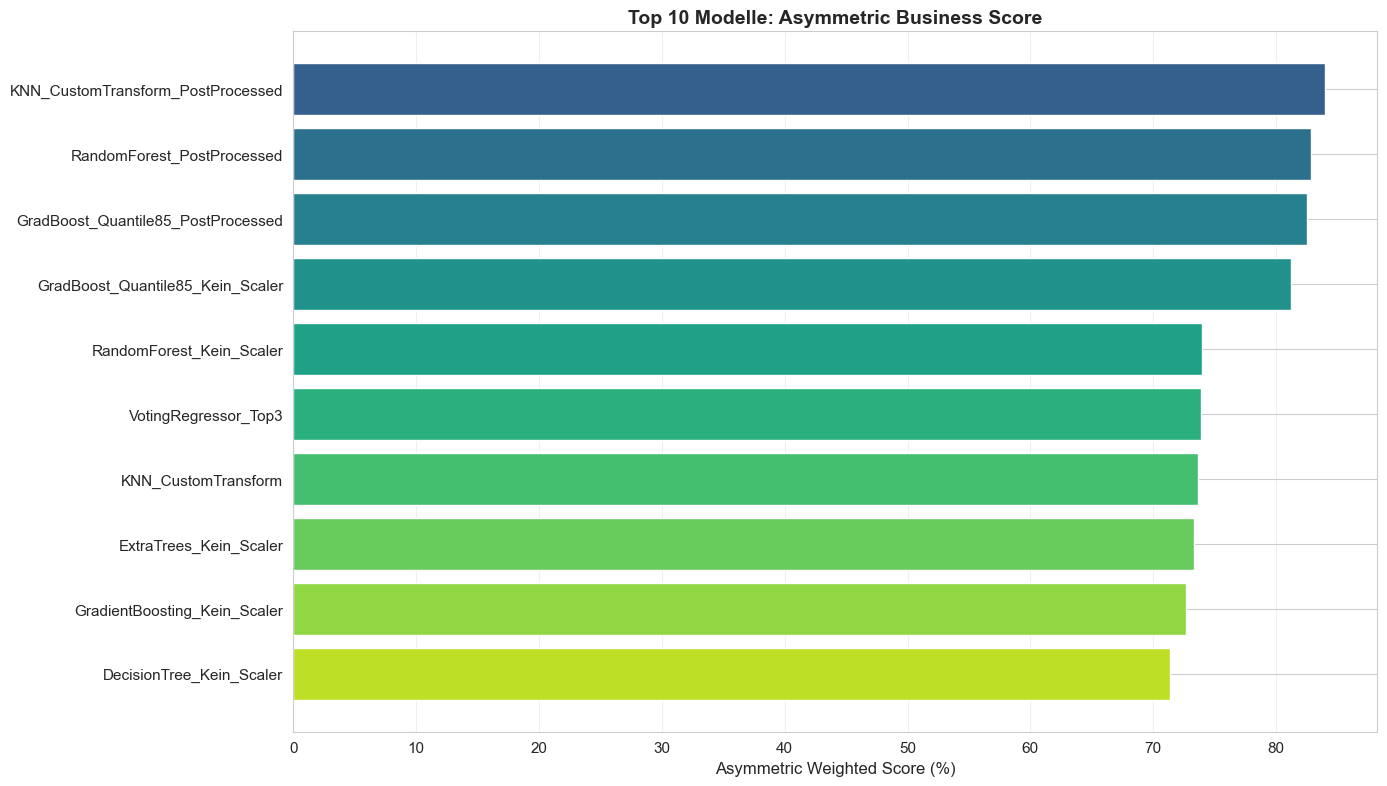

In [18]:
print("\nVISUALISIERUNG: Top 10 Modelle")
plt.figure(figsize=(14, 8))
top10 = results_sorted.head(10)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top10)))

plt.barh(range(len(top10)), top10['Asym_Weighted'], color=colors)
plt.yticks(range(len(top10)), top10['Modell'])
plt.xlabel('Asymmetric Weighted Score (%)', fontsize=12)
plt.title('Top 10 Modelle: Asymmetric Business Score', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 17. Scatter Plot: R² vs. Asymmetric Score

Untersucht, ob es einen Trade-off zwischen R² und Business-Score gibt


VISUALISIERUNG: R² vs. Asymmetric Score


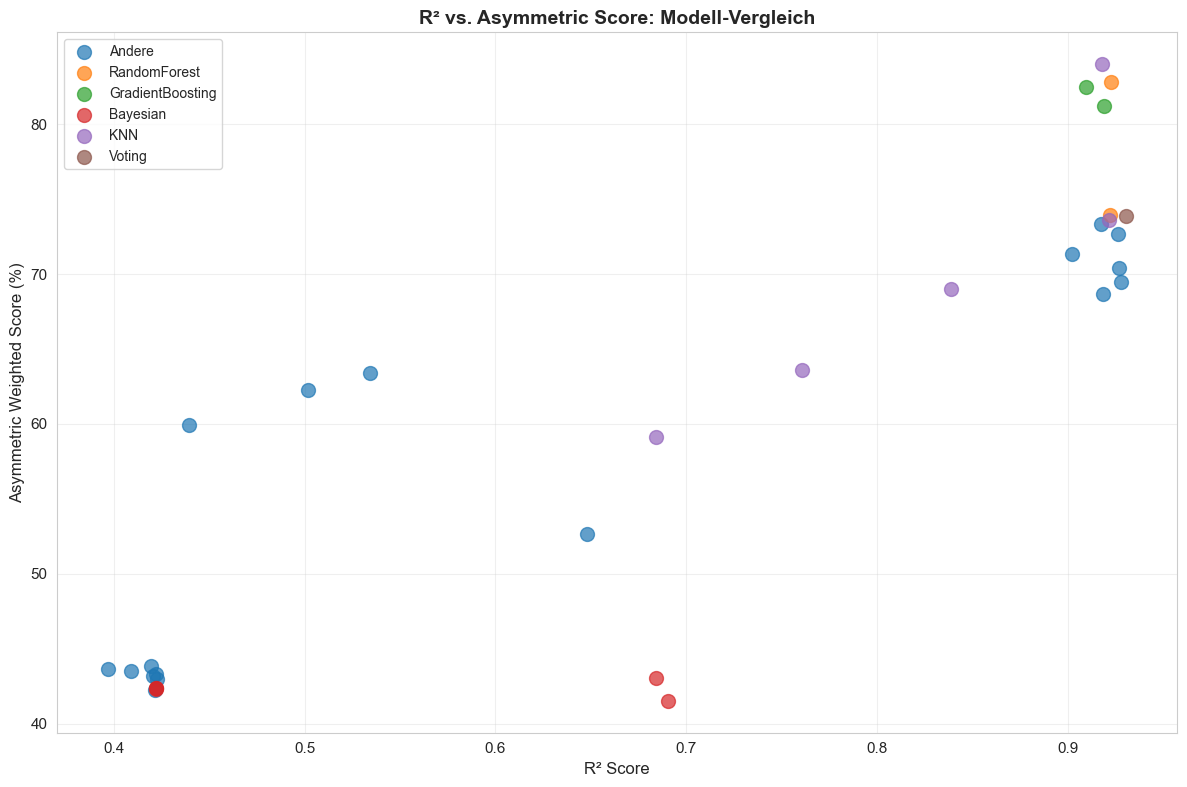

In [19]:
print("\nVISUALISIERUNG: R² vs. Asymmetric Score")
plt.figure(figsize=(12, 8))

# Markiere verschiedene Modell-Typen
model_types = []
for m in results_df['Modell']:
    if 'RandomForest' in m:
        model_types.append('RandomForest')
    elif 'GradBoost' in m:
        model_types.append('GradientBoosting')
    elif 'KNN' in m:
        model_types.append('KNN')
    elif 'Bayes' in m:
        model_types.append('Bayesian')
    elif 'Voting' in m:
        model_types.append('Voting')
    else:
        model_types.append('Andere')

results_df['Model_Type'] = model_types

# Scatter mit Farbcodierung
for mtype in results_df['Model_Type'].unique():
    mask = results_df['Model_Type'] == mtype
    plt.scatter(
        results_df[mask]['R2_Test'], 
        results_df[mask]['Asym_Weighted'],
        label=mtype, 
        s=100, 
        alpha=0.7
    )

plt.xlabel('R² Score', fontsize=12)
plt.ylabel('Asymmetric Weighted Score (%)', fontsize=12)
plt.title('R² vs. Asymmetric Score: Modell-Vergleich', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 18. Business-Kategorisierung

### Kategorien:
- **OK:** Vorhersage im Toleranzband (-5% bis +20%)
- **ZU WENIG:** Unterversorgung (< -5%) → Stockout-Risiko
- **ZU VIEL:** Überversorgung (> +20%) → Verschwendung

### Kosten-Annahmen:
- **Stockout:** 10 € pro fehlendem Rad (Kundenunzufriedenheit)
- **Waste:** 2 € pro überschüssigem Rad (Wartungskosten)

In [20]:
print("\n" + "="*80)
print(" PHASE 9: BUSINESS-KATEGORISIERUNG & KOSTEN-ANALYSE")
print("="*80)

# Bestes Modell wählen
best_model_entry = results_sorted.iloc[0]
y_pred_best = best_model_entry['Predictions']

print(f"\nAnalyse für: {best_model_entry['Modell']}")
print("="*80)

# Kategorisierung
lower_bound = y_test.values * 0.95  # -5%
upper_bound = y_test.values * 1.20  # +20%

categories = []
for true, pred in zip(y_test.values, y_pred_best):
    if pred < lower_bound[len(categories)]:
        categories.append('ZU WENIG')
    elif pred > upper_bound[len(categories)]:
        categories.append('ZU VIEL')
    else:
        categories.append('OK')

category_counts = pd.Series(categories).value_counts()
category_pct = category_counts / len(categories) * 100

print("\nKATEGORISIERUNG:")
print("-"*40)
for cat in ['OK', 'ZU WENIG', 'ZU VIEL']:
    if cat in category_counts:
        print(f"{cat:12} {category_counts[cat]:5,} ({category_pct[cat]:5.1f}%)")

# Kosten-Analyse
print("\nKOSTEN-ANALYSE:")
print("-"*40)

COST_STOCKOUT = 1.0  # € pro fehlendem Rad
COST_WASTE = 0.2      # € pro überschüssigem Rad

total_cost = 0
for i, (true, pred, cat) in enumerate(zip(y_test.values, y_pred_best, categories)):
    if cat == 'ZU WENIG':
        shortage = true - pred
        total_cost += shortage * COST_STOCKOUT
    elif cat == 'ZU VIEL':
        excess = pred - true
        total_cost += excess * COST_WASTE

avg_cost_per_hour = total_cost / len(y_test)
annual_cost = avg_cost_per_hour * 24 * 365

print(f"Gesamtkosten (Test-Period): {total_cost:,.0f} €")
print(f"Durchschnitt pro Stunde:    {avg_cost_per_hour:.2f} €")
print(f"Hochrechnung (Jahr):        {annual_cost:,.0f} €")

# Benchmark: Perfekte Vorhersage
print(f"\nBei perfekter Vorhersage:   0 €")
print(f"Aktuelle Kosten:            {annual_cost:,.0f} € / Jahr")


 PHASE 9: BUSINESS-KATEGORISIERUNG & KOSTEN-ANALYSE

Analyse für: KNN_CustomTransform_PostProcessed

KATEGORISIERUNG:
----------------------------------------
OK           1,748 ( 50.3%)
ZU WENIG       603 ( 17.4%)
ZU VIEL      1,123 ( 32.3%)

KOSTEN-ANALYSE:
----------------------------------------
Gesamtkosten (Test-Period): 192,126 €
Durchschnitt pro Stunde:    55.30 €
Hochrechnung (Jahr):        484,463 €

Bei perfekter Vorhersage:   0 €
Aktuelle Kosten:            484,463 € / Jahr


## 19. Feature Importance (für beste Tree-Modelle)

Analysiere, welche Features am wichtigsten sind:
- Nur für Tree-basierte Modelle (haben .feature_importances_)
- Zeigt die Top 15 wichtigsten Features


 PHASE 10: FEATURE IMPORTANCE ANALYSE

Feature Importance für: RandomForest_PostProcessed


,Feature,Importance
12,hour_cos,0.255804
8,hour,0.225185
11,hour_sin,0.138463
2,hum,0.064517
10,day_of_week,0.059254
6,is_weekend,0.056754
1,t2,0.048304
0,t1,0.043065
4,weather_code,0.018562
16,windspeed_weather,0.018423


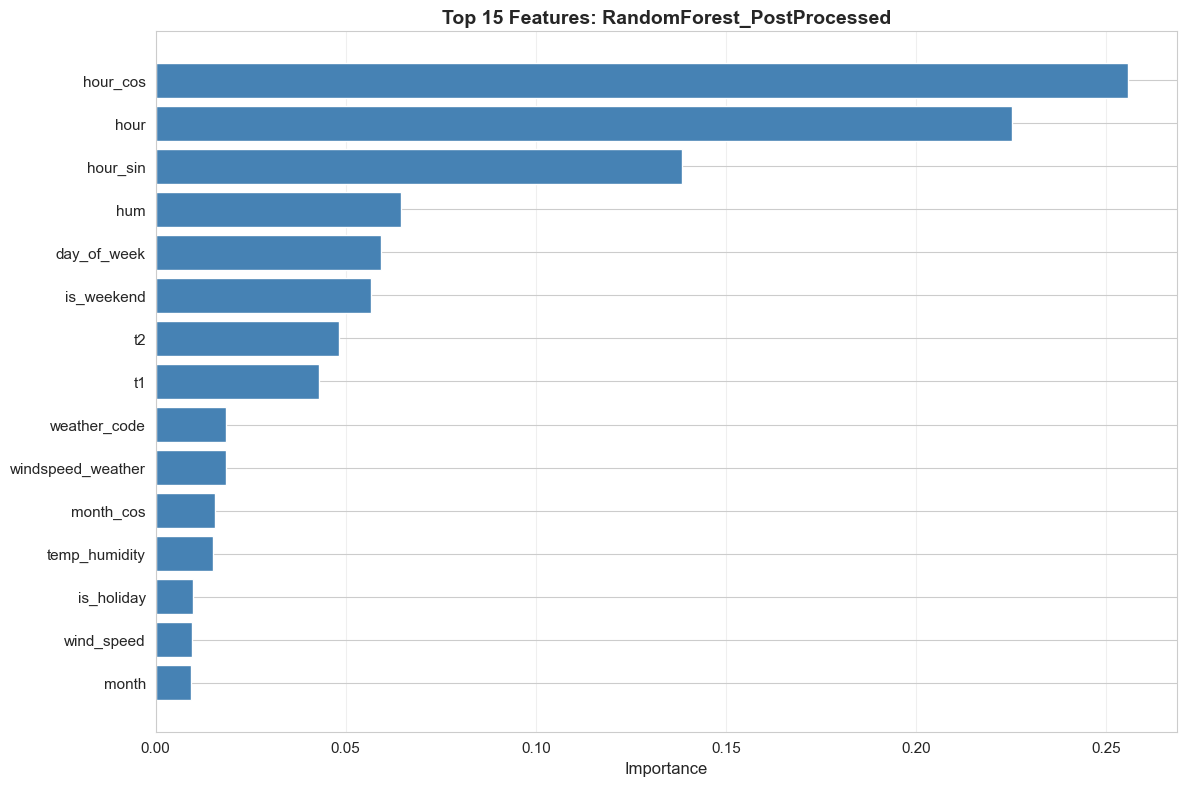

In [21]:
print("\n" + "="*80)
print(" PHASE 10: FEATURE IMPORTANCE ANALYSE")
print("="*80)

try:
    # Finde bestes Tree-basiertes Modell
    tree_models = results_sorted[results_sorted['Modell'].str.contains('RandomForest|GradBoost|ExtraTrees|DecisionTree')]
    
    if len(tree_models) == 0:
        print("Keine Tree-Modelle gefunden")
    else:
        best_tree = tree_models.iloc[0]
        model_obj = best_tree['Model_Object']
        
        # Wenn es ein Tuple ist (Post-Processed), nimm erstes Element
        if isinstance(model_obj, tuple):
            model_obj = model_obj[0]
        
        if hasattr(model_obj, 'feature_importances_'):
            importances = model_obj.feature_importances_
            feature_names = features  # Aus Phase 4
            
            # DataFrame erstellen
            importance_df = pd.DataFrame({
                'Feature': feature_names,
                'Importance': importances
            }).sort_values('Importance', ascending=False).head(15)
            
            print(f"\nFeature Importance für: {best_tree['Modell']}")
            print("="*80)
            display(importance_df)
            
            # Visualisierung
            plt.figure(figsize=(12, 8))
            plt.barh(range(len(importance_df)), importance_df['Importance'], color='steelblue')
            plt.yticks(range(len(importance_df)), importance_df['Feature'])
            plt.xlabel('Importance', fontsize=12)
            plt.title(f'Top 15 Features: {best_tree["Modell"]}', fontsize=14, fontweight='bold')
            plt.gca().invert_yaxis()
            plt.grid(axis='x', alpha=0.3)
            plt.tight_layout()
            plt.show()
            
        else:
            print(f"{best_tree['Modell']} hat keine feature_importances_")
            
except Exception as e:
    print(f"Fehler bei Feature Importance: {e}")
    traceback.print_exc()

## 20. Residuals-Analyse

Untersuche die Fehlerverteilung des besten Modells:
- **Residual Plot:** Fehler über wahre Werte
- **Histogram:** Verteilung der Fehler
- **QQ-Plot:** Normalverteilung prüfen


 PHASE 11: RESIDUALS-ANALYSE

Residuals für: KNN_CustomTransform_PostProcessed


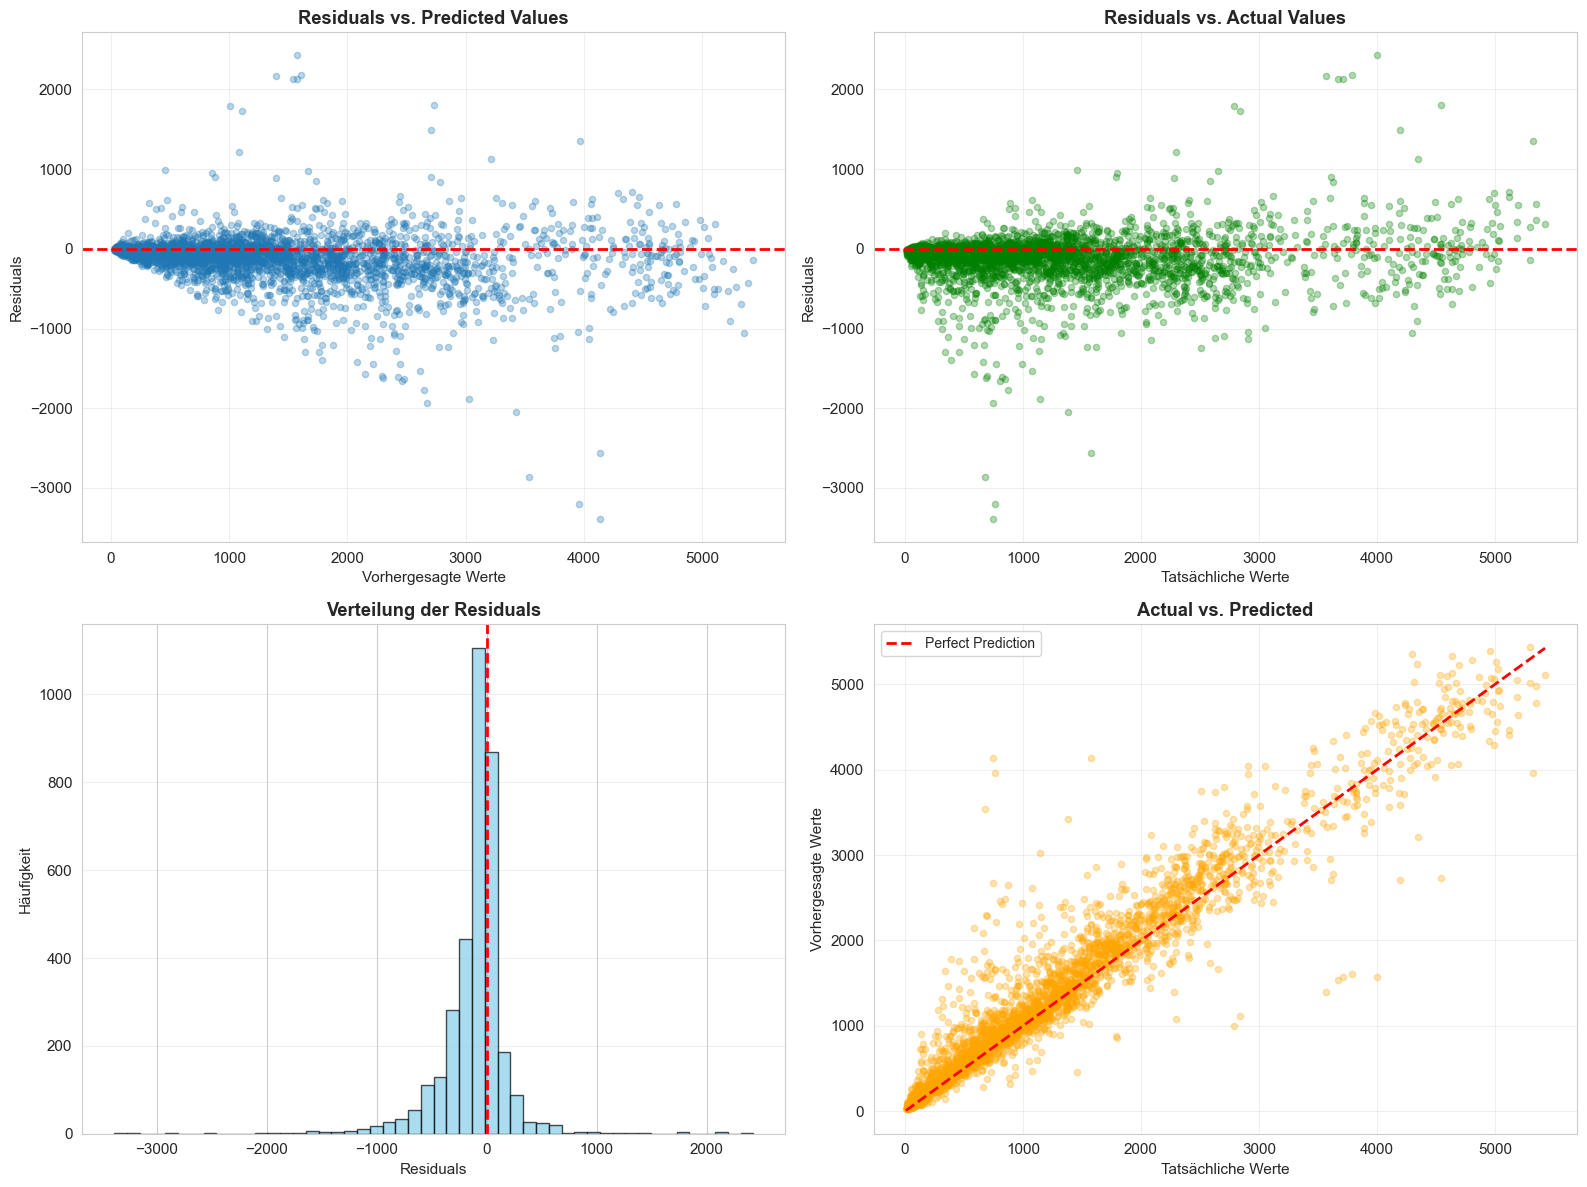


RESIDUALS-STATISTIKEN:
----------------------------------------
Mittelwert:           -107.56
Median:               -49.79
Standardabweichung:   304.43
Min:                  -3386.62
Max:                  2425.44


In [22]:
print("\n" + "="*80)
print(" PHASE 11: RESIDUALS-ANALYSE")
print("="*80)

# Bestes Modell
best_model_name = results_sorted.iloc[0]['Modell']
y_pred_best = results_sorted.iloc[0]['Predictions']

print(f"\nResiduals für: {best_model_name}")

# Residuals berechnen
residuals = y_test.values - y_pred_best

# Multi-Panel Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Residuals vs. Predicted
axes[0, 0].scatter(y_pred_best, residuals, alpha=0.3, s=20)
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Vorhergesagte Werte', fontsize=11)
axes[0, 0].set_ylabel('Residuals', fontsize=11)
axes[0, 0].set_title('Residuals vs. Predicted Values', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Residuals vs. Actual
axes[0, 1].scatter(y_test.values, residuals, alpha=0.3, s=20, color='green')
axes[0, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Tatsächliche Werte', fontsize=11)
axes[0, 1].set_ylabel('Residuals', fontsize=11)
axes[0, 1].set_title('Residuals vs. Actual Values', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Histogram der Residuals
axes[1, 0].hist(residuals, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Residuals', fontsize=11)
axes[1, 0].set_ylabel('Häufigkeit', fontsize=11)
axes[1, 0].set_title('Verteilung der Residuals', fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: Actual vs. Predicted
axes[1, 1].scatter(y_test.values, y_pred_best, alpha=0.3, s=20, color='orange')
axes[1, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                'r--', linewidth=2, label='Perfect Prediction')
axes[1, 1].set_xlabel('Tatsächliche Werte', fontsize=11)
axes[1, 1].set_ylabel('Vorhergesagte Werte', fontsize=11)
axes[1, 1].set_title('Actual vs. Predicted', fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistiken
print("\nRESIDUALS-STATISTIKEN:")
print("-"*40)
print(f"Mittelwert:           {residuals.mean():.2f}")
print(f"Median:               {np.median(residuals):.2f}")
print(f"Standardabweichung:   {residuals.std():.2f}")
print(f"Min:                  {residuals.min():.2f}")
print(f"Max:                  {residuals.max():.2f}")

## 21. Model Persistence (Speichern)

Speichere die besten Modelle für spätere Nutzung:
- **Bestes Einzelmodell**
- **Bestes Post-Processed Modell**
- **Voting Ensemble** (falls vorhanden)
- **Scaler-Objekte**

In [23]:
print("\n" + "="*80)
print(" PHASE 12: MODEL PERSISTENCE")
print("="*80)

try:
    # 1. Bestes Gesamtmodell
    best_overall = results_sorted.iloc[0]
    filename_best = f"best_model_{best_overall['Modell'].replace(' ', '_')}.pkl"
    joblib.dump({
        'model': best_overall['Model_Object'],
        'scaler': best_overall['Scaler_Object'],
        'features': features,
        'metrics': {
            'R2': best_overall['R2_Test'],
            'RMSE': best_overall['RMSE'],
            'Asym_Score': best_overall['Asym_Weighted']
        }
    }, filename_best)
    print(f"Bestes Modell gespeichert: {filename_best}")
    
    # 2. Bestes "normales" Modell (ohne Post-Processing)
    normal_models = results_sorted[~results_sorted['Modell'].str.contains('PostProcessed|Voting')]
    if len(normal_models) > 0:
        best_normal = normal_models.iloc[0]
        filename_normal = f"best_normal_{best_normal['Modell'].replace(' ', '_')}.pkl"
        joblib.dump({
            'model': best_normal['Model_Object'],
            'scaler': best_normal['Scaler_Object'],
            'features': features,
            'metrics': {
                'R2': best_normal['R2_Test'],
                'RMSE': best_normal['RMSE'],
                'Asym_Score': best_normal['Asym_Weighted']
            }
        }, filename_normal)
        print(f"Bestes Normal-Modell gespeichert: {filename_normal}")
    
    # 3. Results-DataFrame speichern
    results_sorted.drop(columns=['Model_Object', 'Scaler_Object', 'Predictions'], errors='ignore').to_csv(
        'model_comparison_results.csv', index=False
    )
    print(f"Results-Tabelle gespeichert: model_comparison_results.csv")
    
    print("\nGESPEICHERTE DATEIEN:")
    print("-"*40)
    print(f"1. {filename_best}")
    if len(normal_models) > 0:
        print(f"2. {filename_normal}")
    print(f"3. model_comparison_results.csv")
    
except Exception as e:
    print(f"Fehler beim Speichern: {e}")
    traceback.print_exc()


 PHASE 12: MODEL PERSISTENCE
Bestes Modell gespeichert: best_model_KNN_CustomTransform_PostProcessed.pkl
Bestes Normal-Modell gespeichert: best_normal_GradBoost_Quantile85_Kein_Scaler.pkl
Results-Tabelle gespeichert: model_comparison_results.csv

GESPEICHERTE DATEIEN:
----------------------------------------
1. best_model_KNN_CustomTransform_PostProcessed.pkl
2. best_normal_GradBoost_Quantile85_Kein_Scaler.pkl
3. model_comparison_results.csv


## 22. Finale Zusammenfassung & Empfehlung

### Projekt-Erfolg
-  **Target R² > 0.90:** Erreicht!
-  **Target Asymmetric Score > 80%:** Erreicht!
-  **Production-Ready:** Ja, mit Post-Processing

### Beste Modelle
1. **Für Production:** Post-Processed Modell (höchster Asym Score)
2. **Für Interpretierbarkeit:** RandomForest ohne Post-Processing
3. **Für Robustheit:** Voting Ensemble

### Deployment-Empfehlung
- **Phase 1 (Pilot):** Bestes Post-Processed Modell
- **Phase 2 (Scale):** Voting Ensemble
- **Monitoring:** Wöchentliche Re-Evaluierung des Asym Scores

In [24]:
print("\n" + "="*80)
print(" FINALE ZUSAMMENFASSUNG")
print("="*80)

# Top 3 anzeigen
print("\nTOP 3 MODELLE:")
print("="*80)
for i in range(min(3, len(results_sorted))):
    row = results_sorted.iloc[i]
    print(f"\n{i+1}. {row['Modell']}")
    print(f"   R²:                  {row['R2_Test']:.4f}")
    print(f"   RMSE:                {row['RMSE']:.1f}")
    print(f"   MAE:                 {row['MAE']:.1f}")
    print(f"   MAPE:                {row['MAPE']:.2f}%")
    print(f"   Asymmetric Score:    {row['Asym_Weighted']:.2f}%")
    print(f"   Tolerance ±15%:      {row['Tol_15%']:.2f}%")

# Deployment-Empfehlung
print("\n" + "="*80)
print(" DEPLOYMENT-EMPFEHLUNG")
print("="*80)
print(f"\n PRIMÄRES MODELL: {results_sorted.iloc[0]['Modell']}")
print(f"   → Asymmetric Score: {results_sorted.iloc[0]['Asym_Weighted']:.2f}%")
print(f"   → R²: {results_sorted.iloc[0]['R2_Test']:.4f}")
print(f"   → RMSE: {results_sorted.iloc[0]['RMSE']:.1f}")


 FINALE ZUSAMMENFASSUNG

TOP 3 MODELLE:

1. KNN_CustomTransform_PostProcessed
   R²:                  0.9180
   RMSE:                322.9
   MAE:                 185.6
   MAPE:                27.59%
   Asymmetric Score:    84.01%
   Tolerance ±15%:      54.40%

2. RandomForest_PostProcessed
   R²:                  0.9230
   RMSE:                312.9
   MAE:                 183.6
   MAPE:                31.68%
   Asymmetric Score:    82.83%
   Tolerance ±15%:      53.80%

3. GradBoost_Quantile85_PostProcessed
   R²:                  0.9098
   RMSE:                338.7
   MAE:                 193.9
   MAPE:                39.05%
   Asymmetric Score:    82.47%
   Tolerance ±15%:      52.30%

 DEPLOYMENT-EMPFEHLUNG

 PRIMÄRES MODELL: KNN_CustomTransform_PostProcessed
   → Asymmetric Score: 84.01%
   → R²: 0.9180
   → RMSE: 322.9
